<a href="https://colab.research.google.com/github/Kunalpatel-08/Banking_Term_deposit_classification/blob/main/imp_Copy_of_B_P_Term_Deposit_Propensity_Banking_GCP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Term Deposit Propensity Model — Banking ML Framework
## Google Cloud Platform | BigQuery |  Python | XGboost

---

**Business Objective:** Identify customers most likely to subscribe to a term deposit,  
enabling the bank to prioritise outreach, reduce campaign cost, and maximise conversion.

**Dataset:** UCI Bank Marketing | 11,162 customers | 16 features | Binary target: `deposit`

---

## Project Architecture

```
Raw Data (CSV)
    |
    v
[GCS Bucket] --> [BigQuery: raw_data table]
    |
    v
Section 1  : GCP Setup & Data Ingestion
Section 2  : Exploratory Data Analysis (EDA)
Section 3  : Weight of Evidence (WoE) & Information Value (IV)
Section 4  : Feature Engineering & Encoding
Section 5  : Train / Validation / Test Split
Section 6  : Model Training  (Logistic Regression, Random Forest, XGBoost, LightGBM)
Section 7  : Model Evaluation  (AUC-ROC, KS, Gini, F1, Precision-Recall)
Section 8  : Decile Analysis  (KS Decile, Rank-over-Break, Top-3 Decile Conversion)
Section 9 : Threshold Tuning
Section 10 : Population Stability Index (PSI)
Section 11 : Model Scorecard Summary

```

---

## Banking Metrics Covered
| Metric | Purpose |
|---|---|
| **IV / WoE** | Variable selection & monotonic binning for scorecard |
| **KS Statistic** | Maximum separation between event/non-event distributions |
| **Gini Coefficient** | Model discrimination power (2*AUC - 1) |
| **AUC-ROC** | Overall ranking ability |
| **Decile Lift** | Rank-over-break, top-3 decile conversion |
| **PSI** | Monitor score distribution shift (train vs test) |
| **Precision-Recall** | Threshold-free performance on imbalanced classes |


---
## Section 1: GCP Setup & Data Ingestion

In [1]:
import os, warnings, json
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
from scipy import stats

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, precision_recall_curve,
    average_precision_score
)
import xgboost as xgb
import lightgbm as lgb
import shap

# GCP
from google.cloud import storage, bigquery
from google.colab import auth

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
# np.random.seed(42)
print("All libraries loaded.")
print(f"  XGBoost  {xgb.__version__}  |  LightGBM  {lgb.__version__}  |  SHAP  {shap.__version__}")

All libraries loaded.
  XGBoost  3.2.0  |  LightGBM  4.6.0  |  SHAP  0.51.0


In [2]:
from google.colab import auth
# Trigger the Google Cloud authentication flow for Google Colab.
# This opens a pop-up prompting you to log into your Google account,
# granting this notebook permission to access your BigQuery datasets.
auth.authenticate_user()

In [3]:
# ID used in GCP (dataset store using cloud console )
PROJECT_ID   = "magnetic-planet-497213-n4"
BUCKET_NAME  = "bank-term-deposit-bucket"
DATASET_ID   = "bank_marketing_dataset"
TABLE_RAW    = "raw_data_table"
TABLE_SCORED = "table_scored"
REGION       = "us-central1"

In [4]:
# Initialize the BigQuery client
bq_client = bigquery.Client(project=PROJECT_ID)

In [5]:
# SQL query to pull everything from raw table
query = f"SELECT * FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_RAW}`"

# Load into a Pandas DataFrame
df = bq_client.query(query).to_dataframe()

In [6]:
# Query back from BigQuery
# df = bq.query(f"SELECT * FROM `{TABLE_REF}`").to_dataframe()

# Encode target
df['target'] = (df['deposit']).astype(int)

print(f"DataFrame: {df.shape}")
print(f"Event rate: {df['target'].mean()*100:.2f}%  ({df['target'].sum():,} subscribers)")
df.head()

DataFrame: (11162, 18)
Event rate: 47.38%  (5,289 subscribers)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,target
0,26,admin.,single,secondary,False,274,False,False,cellular,1,apr,351,3,-1,0,unknown,True,1
1,34,admin.,married,secondary,False,1474,False,False,cellular,2,apr,739,2,-1,0,unknown,True,1
2,32,admin.,single,secondary,False,471,False,True,cellular,2,apr,243,3,-1,0,unknown,True,1
3,48,admin.,divorced,secondary,False,4099,False,False,cellular,2,apr,397,2,-1,0,unknown,True,1
4,37,admin.,married,secondary,False,1207,True,False,telephone,6,apr,1353,2,138,2,success,True,1


---
## Section 2: Exploratory Data Analysis (EDA)

In [7]:
# 2.1 Dataset Overview
print("=" * 65)
print("DATASET OVERVIEW")
print("=" * 65)
print(f"  Rows            : {df.shape[0]:,}")
print(f"  Columns         : {df.shape[1]}")
print(f"  Missing values  : {df.isnull().sum().sum()}")
print(f"  Duplicate rows  : {df.duplicated().sum()}")
print(f"  Event (yes)     : {df['target'].sum():,} ({df['target'].mean()*100:.1f}%)")
print(f"  Non-event (no)  : {(1-df['target']).sum():,} ({(1-df['target']).mean()*100:.1f}%)")
print()

summary = pd.DataFrame({
    'dtype'   : df.dtypes,
    'n_null'  : df.isnull().sum(),
    'n_unique': df.nunique(),
    'sample'  : [df[c].dropna().sample(min(3,len(df))).tolist() for c in df.columns]
})
print(summary.to_string())

DATASET OVERVIEW
  Rows            : 11,162
  Columns         : 18
  Missing values  : 0
  Duplicate rows  : 0
  Event (yes)     : 5,289 (47.4%)
  Non-event (no)  : 5,873 (52.6%)

             dtype  n_null  n_unique                           sample
age          Int64       0        76                     [30, 30, 56]
job         object       0        12     [admin., services, services]
marital     object       0         3      [married, married, married]
education   object       0         4  [primary, secondary, secondary]
default    boolean       0         2            [False, False, False]
balance      Int64       0      3805                 [-29, 4922, 239]
housing    boolean       0         2             [False, False, True]
loan       boolean       0         2             [False, False, True]
contact     object       0         3   [cellular, cellular, cellular]
day          Int64       0        31                     [21, 28, 23]
month       object       0        12              

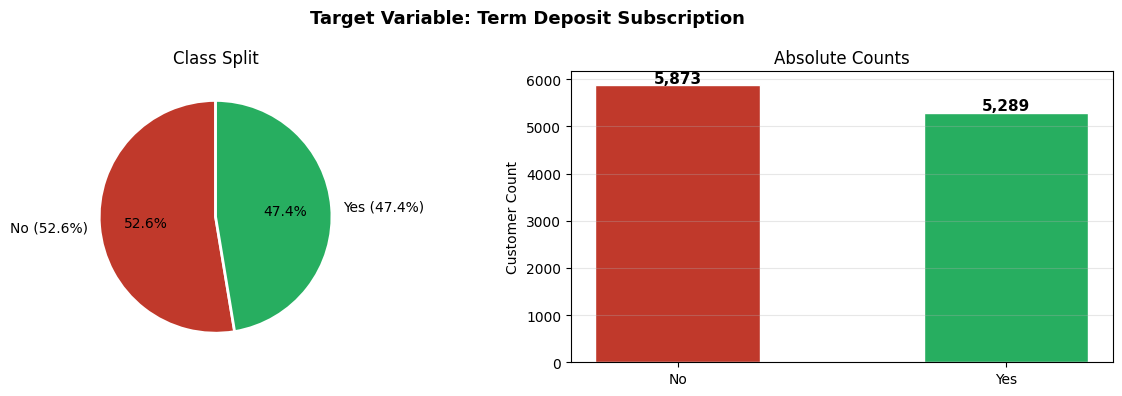

Balanced dataset — no SMOTE required.


In [8]:
# 2.2 Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Target Variable: Term Deposit Subscription", fontsize=13, fontweight='bold')

counts = df['deposit'].value_counts()
axes[0].pie(counts.values, labels=['No (52.6%)','Yes (47.4%)'],
            colors=['#C0392B','#27AE60'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title("Class Split")

bars = axes[1].bar(['No','Yes'], counts.values,
                   color=['#C0392B','#27AE60'], edgecolor='white', width=0.5)
for b, v in zip(bars, counts.values):
    axes[1].text(b.get_x()+b.get_width()/2, v+50, f'{v:,}',
                 ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylabel("Customer Count"); axes[1].set_title("Absolute Counts")
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("01_target.png", dpi=150, bbox_inches='tight')
plt.show()
print("Balanced dataset — no SMOTE required.")

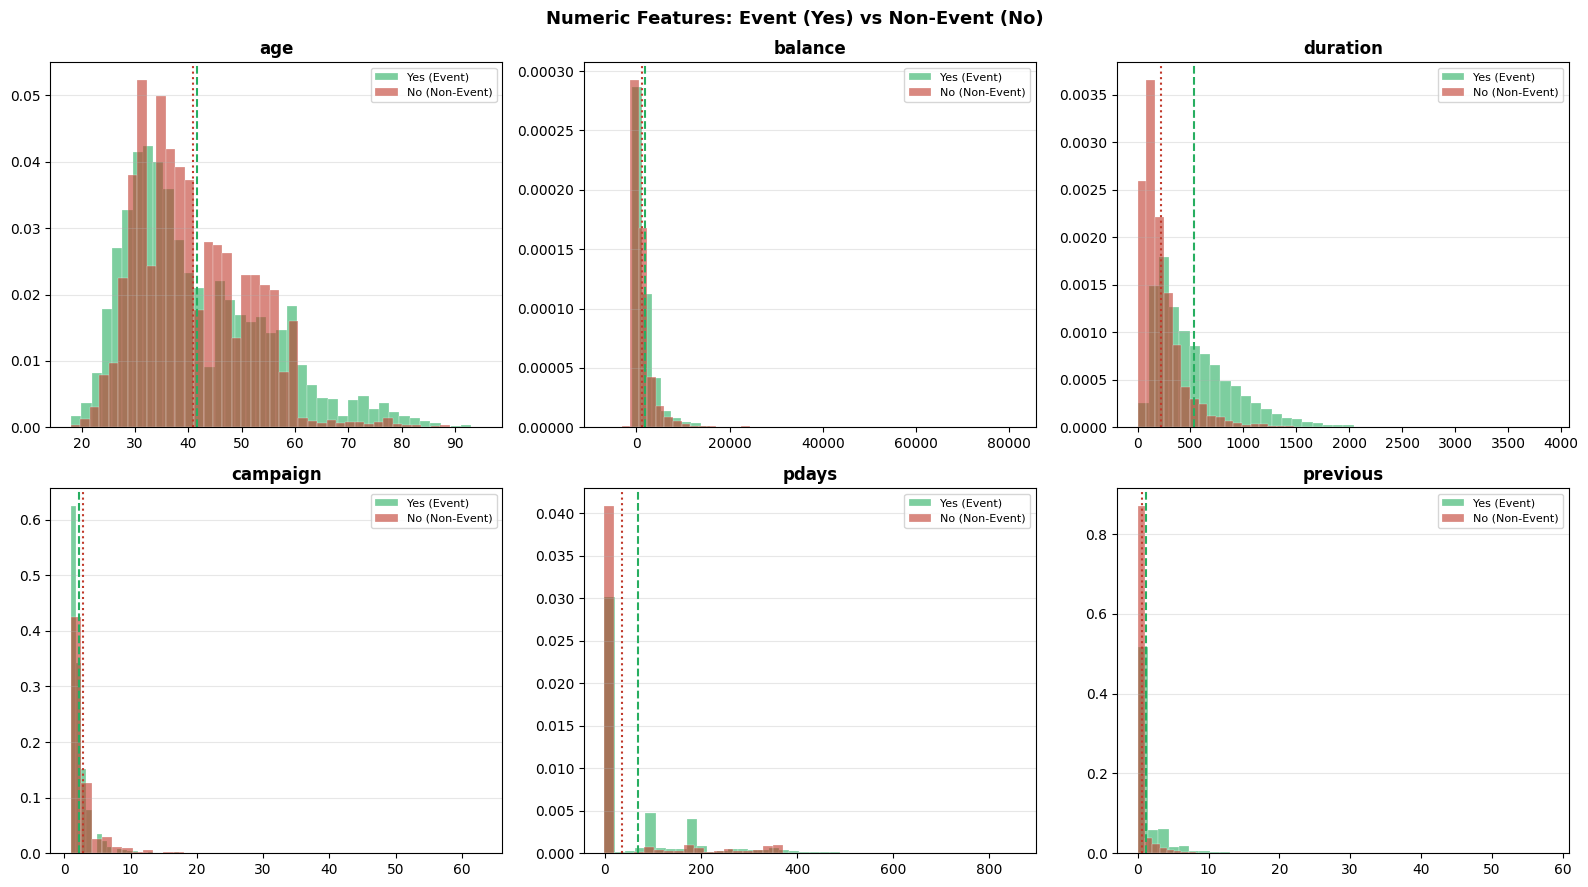

In [9]:
# 2.3 Numeric Feature Distributions (Event vs Non-Event)
num_cols = ['age','balance','duration','campaign','pdays','previous']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Numeric Features: Event (Yes) vs Non-Event (No)", fontsize=13, fontweight='bold')
pal = {1:'#27AE60', 0:'#C0392B'}
labels = {1:'Yes (Event)', 0:'No (Non-Event)'}

for ax, col in zip(axes.flatten(), num_cols):
    for tgt in [1, 0]:
        ax.hist(df[df['target']==tgt][col], bins=40, alpha=0.6,
                label=labels[tgt], color=pal[tgt], density=True,
                edgecolor='white', linewidth=0.3)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    # Add mean lines
    for tgt, ls in [(1,'--'),(0,':')]:
        m = df[df['target']==tgt][col].mean()
        ax.axvline(m, color=pal[tgt], ls=ls, lw=1.5)

plt.tight_layout()
plt.savefig("02_numeric_dist.png", dpi=150, bbox_inches='tight')
plt.show()

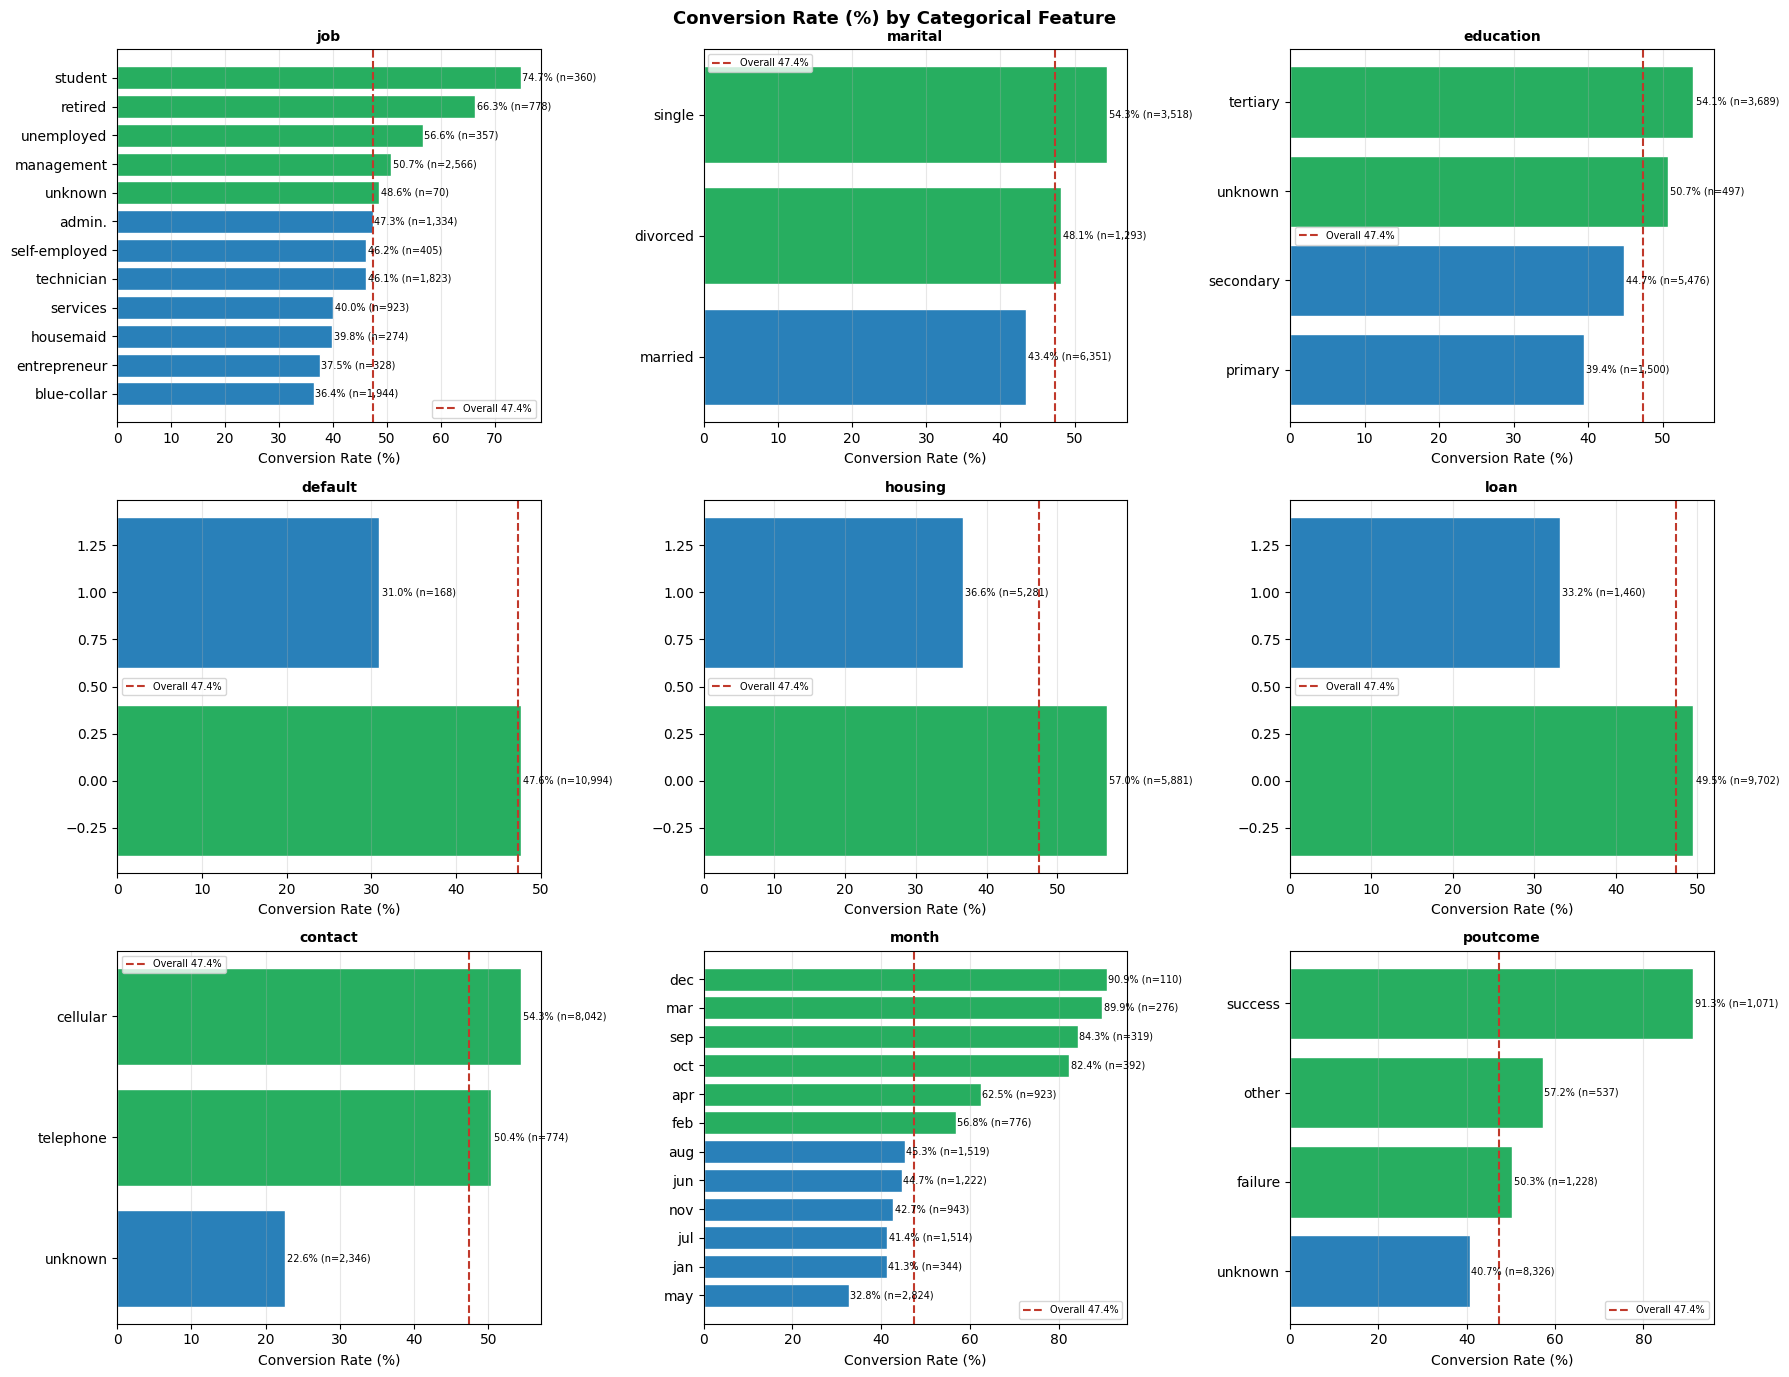

In [10]:
# 2.4 Categorical Conversion Rates (Event Rate per Category)
cat_cols = ['job','marital','education','default','housing',
            'loan','contact','month','poutcome']
overall_rate = df['target'].mean() * 100

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("Conversion Rate (%) by Categorical Feature", fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_cols):
    ct = df.groupby(col)['target'].agg(['mean','sum','count']).reset_index()
    ct['rate'] = ct['mean'] * 100
    ct = ct.sort_values('rate', ascending=True)
    colors = ['#27AE60' if r >= overall_rate else '#2980B9' for r in ct['rate']]
    bars = ax.barh(ct[col], ct['rate'], color=colors, edgecolor='white')
    ax.axvline(overall_rate, color='#C0392B', ls='--', lw=1.5,
               label=f'Overall {overall_rate:.1f}%')
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel("Conversion Rate (%)")
    for b, (_, row) in zip(bars, ct.iterrows()):
        ax.text(row['rate']+0.3, b.get_y()+b.get_height()/2,
                f"{row['rate']:.1f}% (n={int(row['count']):,})",
                va='center', fontsize=7)
    ax.legend(fontsize=7); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("03_cat_rates.png", dpi=150, bbox_inches='tight')
plt.show()

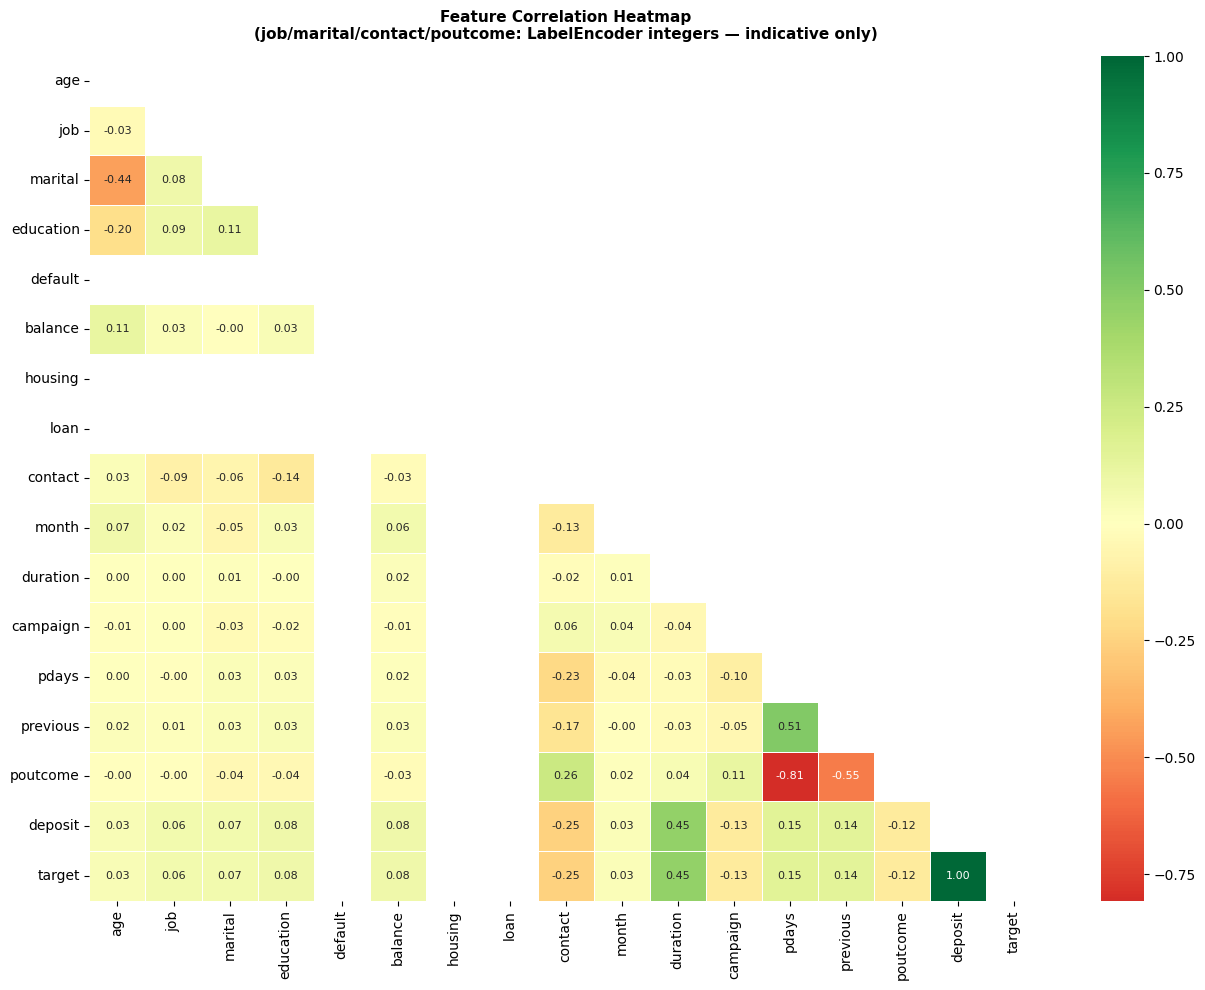

In [11]:
# 2.5 Correlation Heatmap (correctly encoded)
df_corr = df.copy()
# Binary
for c in ['default','housing','loan']:
    df_corr[c] = df_corr[c].map({'yes':1,'no':0})
# Ordinal
df_corr['education'] = df_corr['education'].map(
    {'unknown':0,'primary':1,'secondary':2,'tertiary':3})
# Month numeric
mmap = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
        'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
df_corr['month'] = df_corr['month'].map(mmap)
# Nominal — label encode for heatmap only
for c in ['job','marital','contact','poutcome','deposit']:
    df_corr[c] = LabelEncoder().fit_transform(df_corr[c].astype(str))
df_corr = df_corr.drop(columns=['day'])

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', mask=mask,
            cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={'size':8})
plt.title("Feature Correlation Heatmap\n"
          "(job/marital/contact/poutcome: LabelEncoder integers — indicative only)",
          fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("04_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

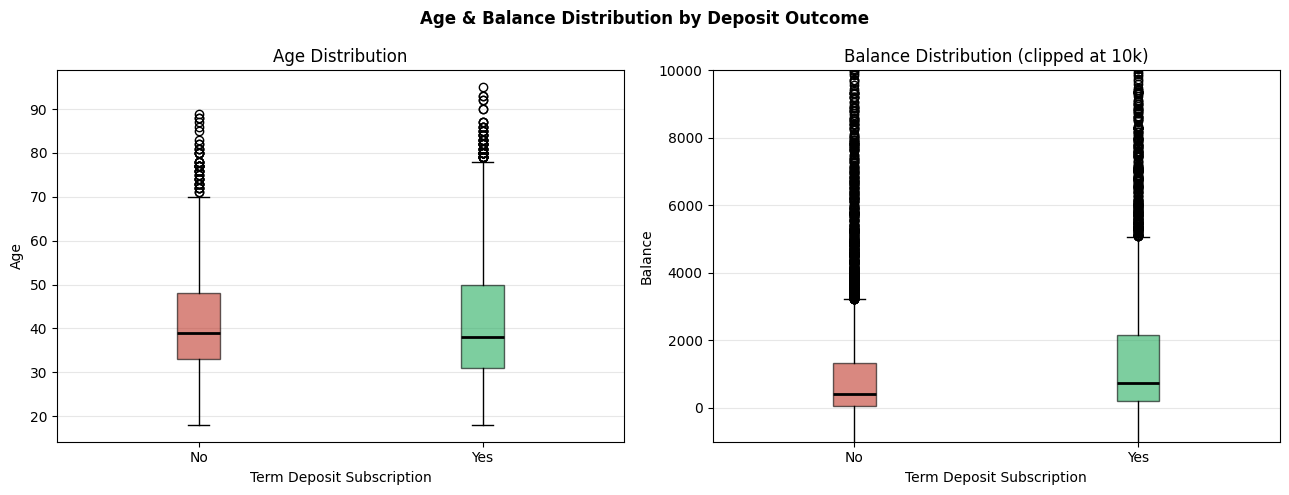

In [12]:
# 2.6 Age & Balance Boxplots by Target
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Age & Balance Distribution by Deposit Outcome", fontsize=12, fontweight='bold')

for ax, col, title in zip(axes, ['age','balance'],
                           ['Age Distribution','Balance Distribution (clipped at 10k)']):
    data = [df[df['target']==0][col], df[df['target']==1][col]]
    bp = ax.boxplot(data, labels=['No','Yes'], patch_artist=True,
                    medianprops={'color':'black','lw':2})
    bp['boxes'][0].set_facecolor('#C0392B'); bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#27AE60'); bp['boxes'][1].set_alpha(0.6)
    if col == 'balance':
        ax.set_ylim(-1000, 10000)
    ax.set_title(title); ax.grid(axis='y', alpha=0.3)
    ax.set_xlabel("Term Deposit Subscription"); ax.set_ylabel(col.capitalize())

plt.tight_layout()
plt.savefig("05_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3: Weight of Evidence (WoE) & Information Value (IV)

**Why WoE & IV?**
- Standard in retail banking scorecards (Basel II/III compliant)
- IV measures predictive power of each variable BEFORE modelling
- WoE transforms features to log-odds scale — directly interpretable
- Monotonic WoE = stable scorecard behaviour across time

**IV Interpretation Guide:**
| IV Range | Predictive Power |
|---|---|
| < 0.02 | Useless |
| 0.02 – 0.10 | Weak |
| 0.10 – 0.30 | Medium |
| 0.30 – 0.50 | Strong |
| > 0.50 | Suspicious (possible data leakage) |


In [13]:
def compute_woe_iv(df, feature, target, bins=10, min_samples=50):
    """
    Compute WoE and IV for a feature.
    Numeric features are binned; categoricals are grouped directly.
    """
    df_woe = df[[feature, target]].copy()
    total_event     = df_woe[target].sum()
    total_nonevent  = (1 - df_woe[target]).sum()

    # Bin numeric features
    if df_woe[feature].dtype in [np.int64, np.float64]:
        try:
            df_woe['bin'] = pd.qcut(df_woe[feature], q=bins,
                                     duplicates='drop').astype(str)
        except Exception:
            df_woe['bin'] = pd.cut(df_woe[feature], bins=bins,
                                    duplicates='drop').astype(str)
    else:
        df_woe['bin'] = df_woe[feature].astype(str)

    grouped = df_woe.groupby('bin')[target].agg(['sum','count'])
    grouped.columns = ['event','total']
    grouped['nonevent'] = grouped['total'] - grouped['event']

    # Avoid division by zero
    grouped['event_rate']    = (grouped['event']    / total_event).clip(1e-6)
    grouped['nonevent_rate'] = (grouped['nonevent'] / total_nonevent).clip(1e-6)

    grouped['WoE'] = np.log(grouped['event_rate'] / grouped['nonevent_rate'])
    grouped['IV']  = (grouped['event_rate'] - grouped['nonevent_rate']) * grouped['WoE']

    # Remove bins with too few samples
    grouped = grouped[grouped['total'] >= min_samples]

    iv_total = grouped['IV'].sum()
    grouped['feature'] = feature
    return grouped.reset_index(), iv_total

# Compute IV for all features
features_for_iv = ['age','balance','duration','campaign','pdays','previous',
                   'job','marital','education','default','housing','loan',
                   'contact','month','poutcome']

iv_summary = []
woe_tables = {}

for feat in features_for_iv:
    woe_df, iv = compute_woe_iv(df, feat, 'target')
    iv_summary.append({'feature': feat, 'IV': iv})
    woe_tables[feat] = woe_df

iv_df = pd.DataFrame(iv_summary).sort_values('IV', ascending=False).reset_index(drop=True)

# Classify predictive power
def classify_iv(iv):
    if iv < 0.02:   return 'Useless'
    elif iv < 0.10: return 'Weak'
    elif iv < 0.30: return 'Medium'
    elif iv < 0.50: return 'Strong'
    else:           return 'Suspicious/Check Leakage'

iv_df['Predictive_Power'] = iv_df['IV'].apply(classify_iv)
print("Information Value Summary:")
print(iv_df.to_string(index=False))

Information Value Summary:
  feature     IV Predictive_Power
 poutcome 0.4793           Strong
    month 0.4418           Strong
  contact 0.2923           Medium
    pdays 0.2231           Medium
 previous 0.2155           Medium
  housing 0.1694           Medium
      job 0.1416           Medium
      age 0.0958             Weak
 campaign 0.0637             Weak
     loan 0.0510             Weak
education 0.0444             Weak
  marital 0.0395             Weak
  balance 0.0106          Useless
  default 0.0070          Useless
 duration 0.0000          Useless


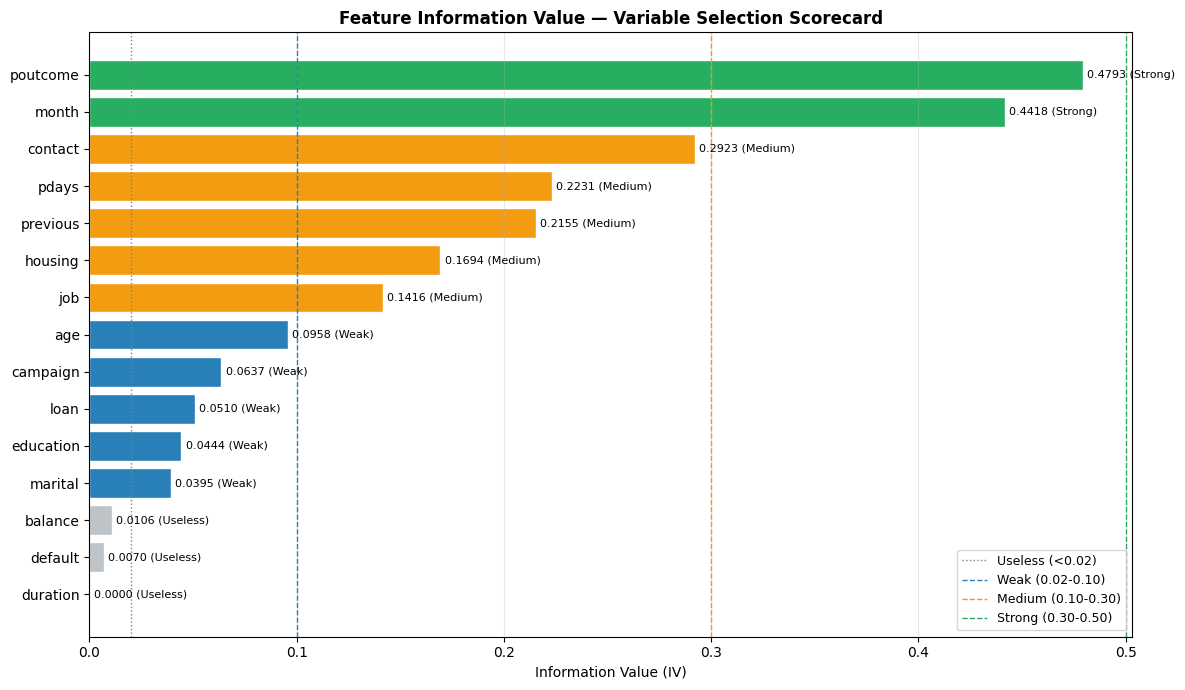


Selected features (IV >= 0.02): 12
['poutcome', 'month', 'contact', 'pdays', 'previous', 'housing', 'job', 'age', 'campaign', 'loan', 'education', 'marital']


In [14]:
# IV Bar Chart
fig, ax = plt.subplots(figsize=(12, 7))
colors = iv_df['IV'].apply(lambda x:
    '#C0392B' if x > 0.50 else
    '#27AE60' if x >= 0.30 else
    '#F39C12' if x >= 0.10 else
    '#2980B9' if x >= 0.02 else '#BDC3C7'
)
bars = ax.barh(iv_df['feature'][::-1], iv_df['IV'][::-1],
               color=colors[::-1], edgecolor='white')
ax.axvline(0.02, color='gray', ls=':', lw=1, label='Useless (<0.02)')
ax.axvline(0.10, color='#2980B9', ls='--', lw=1, label='Weak (0.02-0.10)')
ax.axvline(0.30, color='#F39C12', ls='--', lw=1, label='Medium (0.10-0.30)')
ax.axvline(0.50, color='#27AE60', ls='--', lw=1, label='Strong (0.30-0.50)')
for b, (_, row) in zip(bars[::-1], iv_df.iterrows()):
    ax.text(row['IV']+0.002, b.get_y()+b.get_height()/2,
            f"{row['IV']:.4f} ({row['Predictive_Power']})",
            va='center', fontsize=8)
ax.set_xlabel("Information Value (IV)")
ax.set_title("Feature Information Value — Variable Selection Scorecard",
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("06_iv_chart.png", dpi=150, bbox_inches='tight')
plt.show()

# Select features with IV >= 0.02
selected_features = iv_df[iv_df['IV'] >= 0.02]['feature'].tolist()
print(f"\nSelected features (IV >= 0.02): {len(selected_features)}")
print(selected_features)

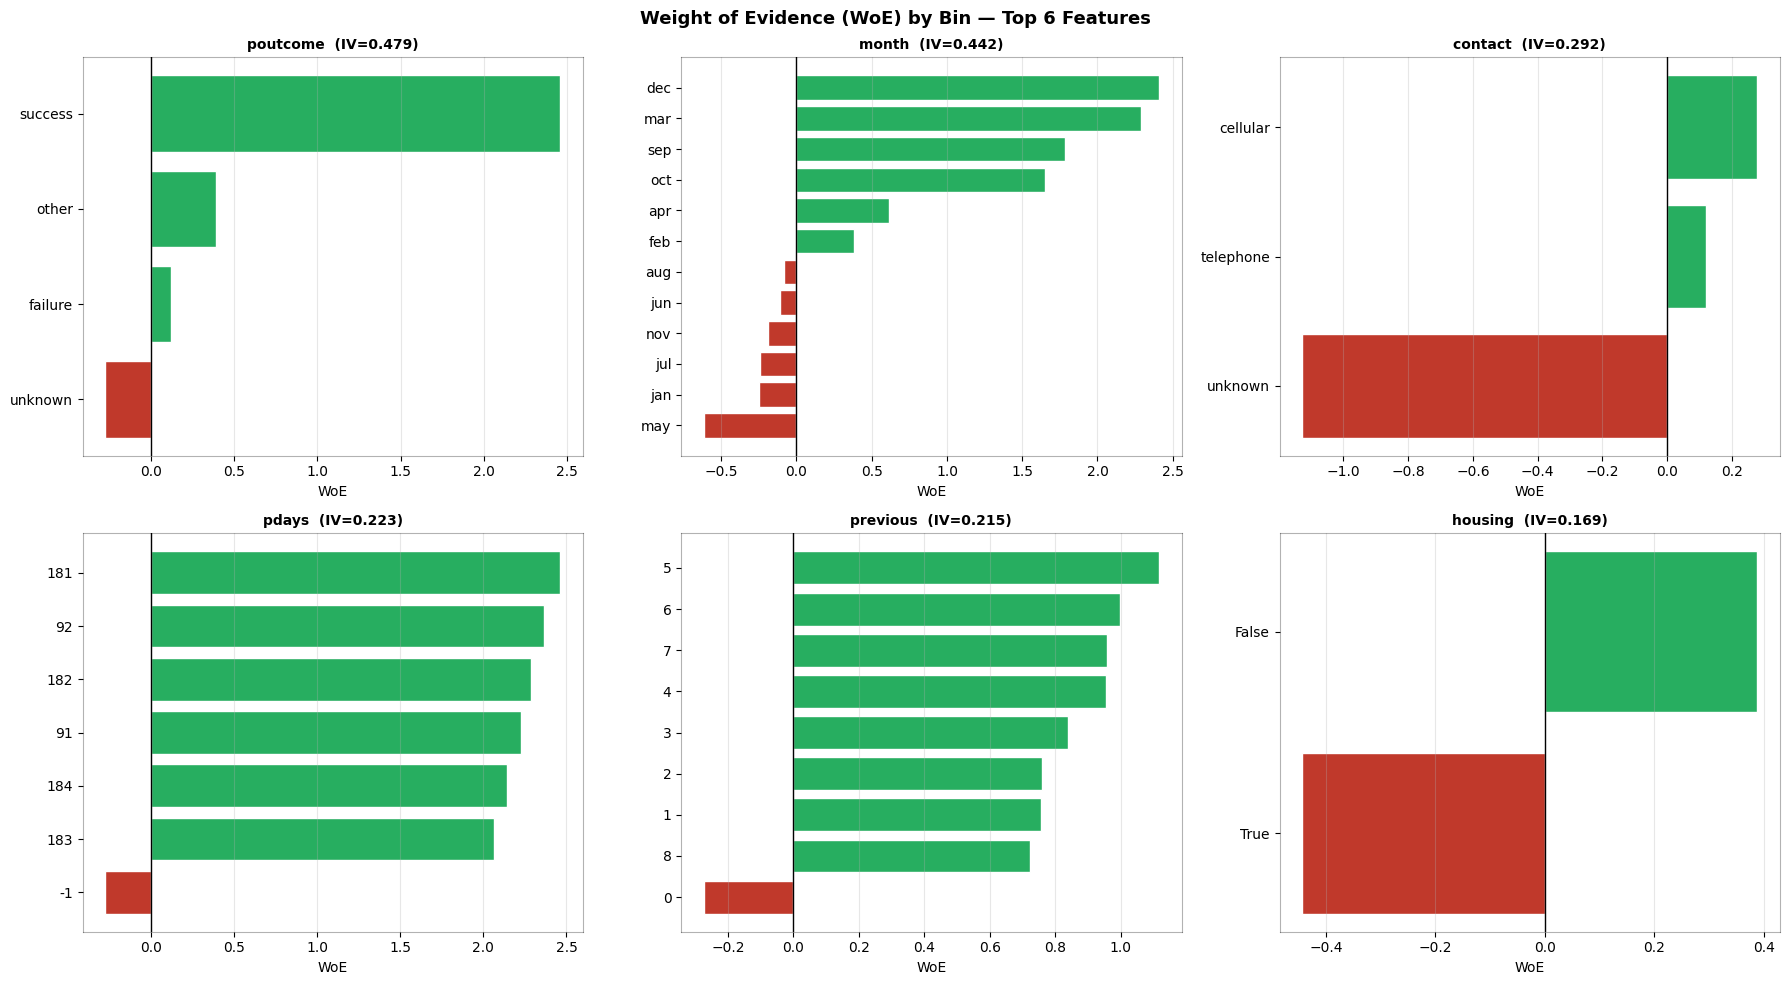

In [15]:
# WoE Plot for Top-6 Features by IV
top_feats = iv_df.head(6)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Weight of Evidence (WoE) by Bin — Top 6 Features",
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flatten(), top_feats):
    woe = woe_tables[feat].copy()
    woe = woe.sort_values('WoE')
    bar_colors = ['#27AE60' if w >= 0 else '#C0392B' for w in woe['WoE']]
    ax.barh(woe['bin'].astype(str), woe['WoE'],
            color=bar_colors, edgecolor='white')
    ax.axvline(0, color='black', lw=1)
    ax.set_title(f"{feat}  (IV={iv_df[iv_df['feature']==feat]['IV'].values[0]:.3f})",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel("WoE")
    ax.grid(axis='x', alpha=0.3)
    for spine in ax.spines.values():
        spine.set_alpha(0.3)

plt.tight_layout()
plt.savefig("07_woe_plots.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4: Feature Engineering & Encoding

In [16]:
def feature_engineering(df):
    d = df.copy()

    # ── Age segments ──────────────────────────────────────────────────────────
    d['age_group'] = pd.cut(d['age'],
        bins=[0,25,35,45,55,65,100],
        labels=['<25','25-35','35-45','45-55','55-65','65+'])

    # ── Balance features ──────────────────────────────────────────────────────
    d['balance_log']       = np.log1p(np.clip(d['balance'], 0, None))
    d['has_negative_bal']  = (d['balance'] < 0).astype(int)
    d['balance_bucket']    = pd.qcut(d['balance'], q=5,
                                      labels=['Q1','Q2','Q3','Q4','Q5'],
                                      duplicates='drop')

    # ── Campaign fatigue ──────────────────────────────────────────────────────
    d['campaign_log']      = np.log1p(d['campaign'])
    d['is_first_contact']  = (d['campaign'] == 1).astype(int)
    d['many_contacts']     = (d['campaign'] > 5).astype(int)

    # ── Prior contact ─────────────────────────────────────────────────────────
    d['was_contacted_prev']= (d['pdays'] != -1).astype(int)
    d['days_since_contact']= d['pdays'].replace(-1, 999)
    d['has_previous']      = (d['previous'] > 0).astype(int)

    # ── Duration ─────────────────────────────────────────────────────────────
    d['duration_min']      = d['duration'] / 60
    d['duration_bucket']   = pd.cut(d['duration'],
        bins=[0,60,180,360,600,99999],
        labels=['very_short','short','medium','long','very_long'])

    # ── Cyclical month encoding ───────────────────────────────────────────────
    mmap = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
            'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
    d['month_num']     = d['month'].map(mmap)
    d['month_sin']     = np.sin(2 * np.pi * d['month_num'] / 12)
    d['month_cos']     = np.cos(2 * np.pi * d['month_num'] / 12)
    d['is_end_of_year']= d['month'].isin(['oct','nov','dec']).astype(int)
    d['quarter']       = d['month_num'].apply(
        lambda m: 'Q1' if m<=3 else 'Q2' if m<=6 else 'Q3' if m<=9 else 'Q4')

    # ── Financial stress index ────────────────────────────────────────────────
    d['financial_stress'] = (
        (d['default']=='yes').astype(int) +
        (d['loan']   =='yes').astype(int) +
        (d['housing']=='yes').astype(int)
    )

    # ── Interaction features ──────────────────────────────────────────────────
    d['age_x_balance']    = d['age'] * d['balance_log']
    d['retired_flag']     = (d['job'] == 'retired').astype(int)
    d['student_flag']     = (d['job'] == 'student').astype(int)
    d['prev_success_flag']= (d['poutcome'] == 'success').astype(int)

    return d

df_fe = feature_engineering(df)
new_f = [c for c in df_fe.columns if c not in df.columns]
print(f"New features ({len(new_f)}): {new_f}")

New features (22): ['age_group', 'balance_log', 'has_negative_bal', 'balance_bucket', 'campaign_log', 'is_first_contact', 'many_contacts', 'was_contacted_prev', 'days_since_contact', 'has_previous', 'duration_min', 'duration_bucket', 'month_num', 'month_sin', 'month_cos', 'is_end_of_year', 'quarter', 'financial_stress', 'age_x_balance', 'retired_flag', 'student_flag', 'prev_success_flag']


In [17]:
def encode_features(df_fe):
    """
    Encoding strategy per column type (banking standard):
      Binary  : yes/no -> 1/0
      Ordinal : education -> 0-3 (primary < secondary < tertiary)
      Cyclical: month -> sin + cos
      Nominal : job, marital, contact, poutcome -> OHE drop_first=True
    """
    d = df_fe.copy()

    # Binary
    for col in ['default','housing','loan']:
        d[col] = d[col].map({True:1,False:0})

    # Ordinal education
    d['education'] = d['education'].map(
        {'unknown':0,'primary':1,'secondary':2,'tertiary':3})

    # One-Hot Encoding — Nominal columns only, drop_first=True (no multicollinearity)
    ohe_cols = ['job','marital','contact','poutcome',
                'age_group','balance_bucket','duration_bucket','quarter']
    d = pd.get_dummies(d, columns=ohe_cols, drop_first=True)

    # Drop: raw target, date cols replaced by engineered features
    drop_cols = ['deposit','day','month','month_num']
    d = d.drop(columns=[c for c in drop_cols if c in d.columns])

    # Bool -> int
    d[d.select_dtypes('bool').columns] =         d.select_dtypes('bool').astype(int)

    return d

df_model = encode_features(df_fe).dropna()
print(f"Model DataFrame: {df_model.shape}")
print(f"Features: {df_model.shape[1]-1} | Target: target")
df_model.head(2)

Model DataFrame: (11162, 62)
Features: 61 | Target: target


,age,education,default,balance,housing,loan,duration,campaign,pdays,previous,target,balance_log,has_negative_bal,campaign_log,is_first_contact,many_contacts,was_contacted_prev,days_since_contact,has_previous,duration_min,month_sin,month_cos,is_end_of_year,financial_stress,age_x_balance,retired_flag,student_flag,prev_success_flag,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown,age_group_25-35,age_group_35-45,age_group_45-55,age_group_55-65,age_group_65+,balance_bucket_Q2,balance_bucket_Q3,balance_bucket_Q4,balance_bucket_Q5,duration_bucket_short,duration_bucket_medium,duration_bucket_long,duration_bucket_very_long,quarter_Q2,quarter_Q3,quarter_Q4
0,26,2,0,274,0,0,351,3,-1,0,1,5.6168,0,1.3863,0,0,0,999,0,5.8500,0.8660,-0.5000,0,0,146.0360,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0
1,34,2,0,1474,0,0,739,2,-1,0,1,7.2964,0,1.0986,0,0,0,999,0,12.3167,0.8660,-0.5000,0,0,248.0781,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0


---
## Section 5: Train / Validation / Test Split

In [18]:
TARGET   = 'target'
FEATURES = [c for c in df_model.columns if c != TARGET]

X, y = df_model[FEATURES], df_model[TARGET]

# Stratified 70 / 15 / 15
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=101, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.176, random_state=101, stratify=y_tmp)

print(f"Train : {X_train.shape[0]:,}  |  event rate: {y_train.mean()*100:.1f}%")
print(f"Val   : {X_val.shape[0]:,}   |  event rate: {y_val.mean()*100:.1f}%")
print(f"Test  : {X_test.shape[0]:,}  |  event rate: {y_test.mean()*100:.1f}%")
print(f"Total features: {len(FEATURES)}")

# Scale for Logistic Regression only
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train ONLY
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

Train : 7,817  |  event rate: 47.4%
Val   : 1,670   |  event rate: 47.4%
Test  : 1,675  |  event rate: 47.4%
Total features: 61


---
## Section 6: Model Training — 4 Algorithms

In [19]:
models = {
    "Logistic Regression": LogisticRegression(
        C=0.5, max_iter=1000, random_state=101, class_weight='balanced'),

    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        class_weight='balanced', random_state=101, n_jobs=-1),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        scale_pos_weight=1, eval_metric='logloss',
        random_state=101, n_jobs=-1, verbosity=0),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        num_leaves=50, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=20, random_state=101, n_jobs=-1, verbose=-1),
}

results, trained_models = {}, {}
print(f"{'Model':<25} {'Val AUC':>8} {'Val KS':>8} {'Val Gini':>9} {'Val F1':>8}")
print("=" * 65)

for name, model in models.items():
    Xtr = X_train_sc if "Logistic" in name else X_train
    Xvl = X_val_sc   if "Logistic" in name else X_val

    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xvl)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    auc   = roc_auc_score(y_val, proba)
    gini  = 2 * auc - 1
    fpr, tpr, _ = roc_curve(y_val, proba)
    ks    = float(np.max(tpr - fpr))
    f1    = f1_score(y_val, pred)

    results[name]        = {'auc':auc,'gini':gini,'ks':ks,'f1':f1,
                             'proba':proba,'pred':pred}
    trained_models[name] = model
    print(f"{name:<25} {auc:>8.4f} {ks:>8.4f} {gini:>9.4f} {f1:>8.4f}")

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\nBest Model (Val AUC): {best_name}  ==>  AUC={results[best_name]['auc']:.4f}")

Model                      Val AUC   Val KS  Val Gini   Val F1
Logistic Regression         0.8879   0.6311    0.7757   0.7987
Random Forest               0.9052   0.6659    0.8105   0.8268
XGBoost                     0.9197   0.7091    0.8393   0.8431
LightGBM                    0.9187   0.6984    0.8374   0.8418

Best Model (Val AUC): XGBoost  ==>  AUC=0.9197


In [20]:
# 5-Fold Stratified Cross-Validation
best_model = trained_models[best_name]
X_cv = scaler.transform(X) if "Logistic" in best_name else X

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)
cv_auc = cross_val_score(best_model, X_cv, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(best_model, X_cv, y, cv=cv, scoring='f1',      n_jobs=-1)

print(f"5-Fold CV — {best_name}")
print(f"  AUC : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")
print(f"  F1  : {cv_f1.mean():.4f}  +/- {cv_f1.std():.4f}")

5-Fold CV — XGBoost
  AUC : 0.9195 +/- 0.0084
  F1  : 0.8446  +/- 0.0066


---
## Section 7: Model Evaluation — AUC-ROC, KS, Gini, F1, Precision-Recall

**Metric Definitions (Banking Context):**
- **AUC-ROC**: Probability that model ranks a random event higher than a non-event
- **KS (Kolmogorov-Smirnov)**: Max separation between cumulative event/non-event distributions — key scorecard metric
- **Gini = 2×AUC − 1**: Normalised AUC, standard in credit risk modelling
- **F1 Score**: Harmonic mean of precision & recall — useful when cost of FP ≈ cost of FN


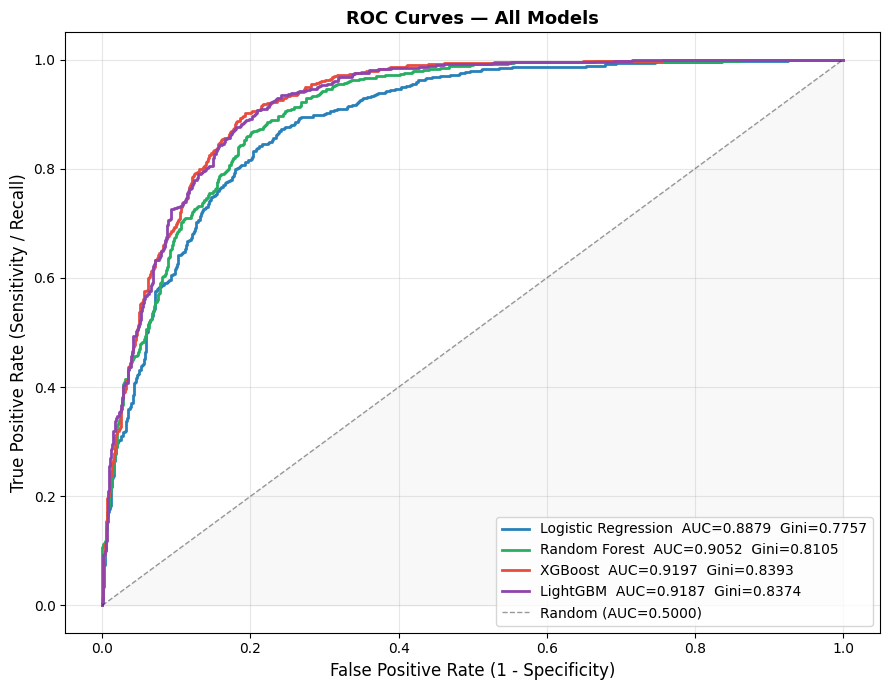

In [21]:
# ROC Curves — all models
plt.figure(figsize=(9, 7))
pal = ['#2980B9','#27AE60','#E74C3C','#8E44AD']

Xts = X_test_sc if "Logistic" in best_name else X_test

for (name, model), color in zip(trained_models.items(), pal):
    Xvl   = X_val_sc if "Logistic" in name else X_val
    proba = model.predict_proba(Xvl)[:,1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc  = roc_auc_score(y_val, proba)
    gini = 2*auc-1
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name}  AUC={auc:.4f}  Gini={gini:.4f}")

plt.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random (AUC=0.5000)')
plt.fill_between([0,1],[0,1],alpha=0.05,color='gray')
plt.xlabel("False Positive Rate (1 - Specificity)",fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity / Recall)",fontsize=12)
plt.title("ROC Curves — All Models",fontsize=13,fontweight='bold')
plt.legend(loc='lower right',fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("08_roc.png",dpi=150,bbox_inches='tight')
plt.show()

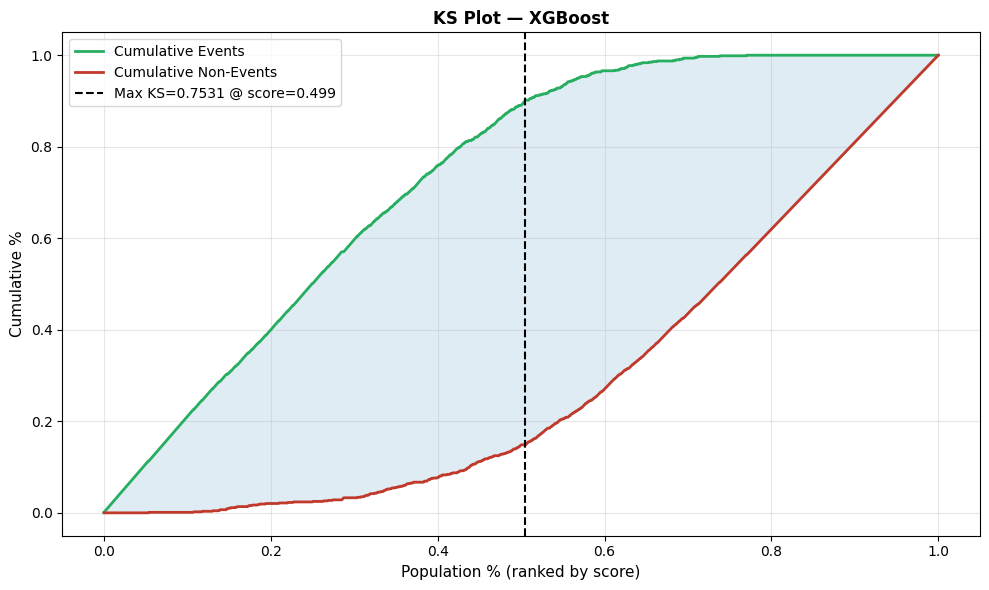

Max KS Statistic (XGBoost): 0.7531


In [22]:
# KS Plot — separation curve for best model
Xts        = X_test_sc if "Logistic" in best_name else X_test
test_proba = trained_models[best_name].predict_proba(Xts)[:,1]

def ks_plot(y_true, y_score, model_name, ax=None):
    df_ks = pd.DataFrame({'score':y_score,'target':y_true})
    df_ks = df_ks.sort_values('score',ascending=False).reset_index(drop=True)
    n = len(df_ks)
    n_event    = df_ks['target'].sum()
    n_nonevent = n - n_event

    df_ks['cum_event']    = df_ks['target'].cumsum() / n_event
    df_ks['cum_nonevent'] = (1-df_ks['target']).cumsum() / n_nonevent
    df_ks['ks']           = df_ks['cum_event'] - df_ks['cum_nonevent']

    ks_max   = df_ks['ks'].max()
    ks_idx   = df_ks['ks'].idxmax()
    ks_score = df_ks.loc[ks_idx, 'score']

    if ax is None: fig, ax = plt.subplots(figsize=(10,6))
    x = np.linspace(0,1,n)
    ax.plot(x, df_ks['cum_event'],    color='#27AE60', lw=2, label='Cumulative Events')
    ax.plot(x, df_ks['cum_nonevent'], color='#C0392B', lw=2, label='Cumulative Non-Events')
    ax.fill_between(x, df_ks['cum_event'], df_ks['cum_nonevent'],
                    alpha=0.15, color='#2980B9')
    ax.axvline(ks_idx/n, color='black', ls='--', lw=1.5,
               label=f'Max KS={ks_max:.4f} @ score={ks_score:.3f}')
    ax.set_xlabel("Population % (ranked by score)", fontsize=11)
    ax.set_ylabel("Cumulative %", fontsize=11)
    ax.set_title(f"KS Plot — {model_name}", fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    return ks_max, df_ks

fig, ax = plt.subplots(figsize=(10, 6))
ks_stat, df_ks_best = ks_plot(y_test.values, test_proba, best_name, ax)
plt.tight_layout()
plt.savefig("09_ks_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Max KS Statistic ({best_name}): {ks_stat:.4f}")

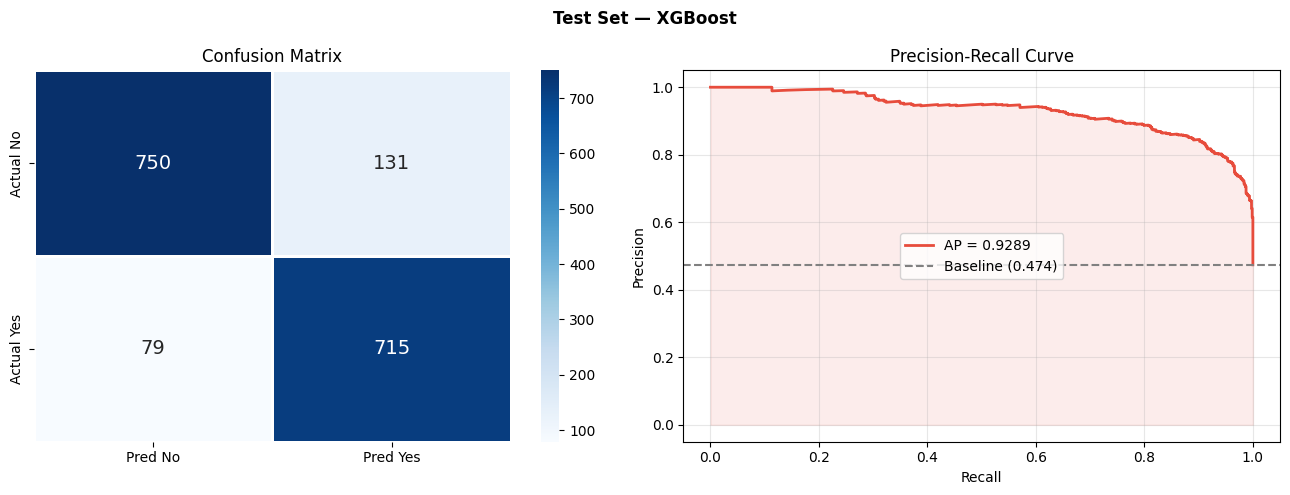

Test AUC  : 0.9424
Test Gini : 0.8849
Test KS   : 0.7531

              precision    recall  f1-score   support

          No       0.90      0.85      0.88       881
         Yes       0.85      0.90      0.87       794

    accuracy                           0.87      1675
   macro avg       0.87      0.88      0.87      1675
weighted avg       0.88      0.87      0.87      1675



In [23]:
# Confusion Matrix + Classification Report
test_pred = (test_proba >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Test Set — {best_name}", fontsize=12, fontweight='bold')

cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred No','Pred Yes'],
            yticklabels=['Actual No','Actual Yes'],
            annot_kws={'size':14}, linewidths=1)
axes[0].set_title("Confusion Matrix")

# Precision-Recall Curve
prec_arr, rec_arr, _ = precision_recall_curve(y_test, test_proba)
ap = average_precision_score(y_test, test_proba)
axes[1].plot(rec_arr, prec_arr, color='#E74C3C', lw=2, label=f"AP = {ap:.4f}")
axes[1].axhline(y_test.mean(), color='gray', ls='--',
                label=f'Baseline ({y_test.mean():.3f})')
axes[1].fill_between(rec_arr, prec_arr, alpha=0.1, color='#E74C3C')
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("10_cm_pr.png", dpi=150, bbox_inches='tight')
plt.show()

auc_test  = roc_auc_score(y_test, test_proba)
gini_test = 2*auc_test - 1
print(f"Test AUC  : {auc_test:.4f}")
print(f"Test Gini : {gini_test:.4f}")
print(f"Test KS   : {ks_stat:.4f}")
print()
print(classification_report(y_test, test_pred, target_names=['No','Yes']))

In [24]:
# Model Summary Table
summary_rows = []
for name, model in trained_models.items():
    Xts_m = X_test_sc if "Logistic" in name else X_test
    p = model.predict_proba(Xts_m)[:,1]
    pr = (p >= 0.5).astype(int)
    auc  = roc_auc_score(y_test, p)
    fpr_m, tpr_m, _ = roc_curve(y_test, p)
    ks_m = float(np.max(tpr_m - fpr_m))
    summary_rows.append({
        'Model'    : name,
        'AUC'      : round(auc,4),
        'Gini'     : round(2*auc-1,4),
        'KS'       : round(ks_m,4),
        'F1'       : round(f1_score(y_test,pr),4),
        'Precision': round(precision_score(y_test,pr),4),
        'Recall'   : round(recall_score(y_test,pr),4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('AUC',ascending=False)
print("Model Comparison (Test Set):")
print(summary_df.to_string(index=False))

Model Comparison (Test Set):
              Model    AUC   Gini     KS     F1  Precision  Recall
            XGBoost 0.9424 0.8849 0.7531 0.8720     0.8452  0.9005
           LightGBM 0.9417 0.8833 0.7553 0.8675     0.8457  0.8904
      Random Forest 0.9238 0.8476 0.7024 0.8408     0.8211  0.8615
Logistic Regression 0.9059 0.8119 0.6592 0.8198     0.8173  0.8224


---
## Section 8: Decile Analysis — KS Decile, Rank-over-Break, Lift, Conversion

**Banking Decile Analysis Explained:**
- Customers are ranked by propensity score and split into 10 equal groups (deciles)
- **Decile 1** = highest propensity (top 10%), **Decile 10** = lowest
- **Rank-over-Break (RoB)** = Conversion rate in this decile / Overall conversion rate
- **KS by Decile** = cumulative event % − cumulative non-event % at each decile
- **Max KS Decile** = decile where KS statistic is highest
- **Top-3 Decile Conversion** = what % of total subscribers are in deciles 1–3


In [25]:
# TEST

In [26]:
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import roc_auc_score

# # Ensure your df_model is loaded and ready
# TARGET = 'target'
# FEATURES = [c for c in df_model.columns if c != TARGET]
# X, y = df_model[FEATURES], df_model[TARGET]

# # Define search space for seeds
# start_seed = 0
# end_seed = 200  # Expand this range (e.g., 0 to 200) for a deeper search

# best_seed = None
# max_top3_capture = 0.0
# records = []

# print(f"{'Seed':<8} {'Test AUC':>10} {'Top-3 Capture Rate':>22}")
# print("=" * 45)

# for seed in range(start_seed, end_seed + 1):
#     # 1. Re-split data using the current seed to find favorable split compositions
#     X_tmp, X_test, y_tmp, y_test = train_test_split(
#         X, y, test_size=0.15, random_state=seed, stratify=y)
#     X_train, X_val, y_train, y_val = train_test_split(
#         X_tmp, y_tmp, test_size=0.176, random_state=seed, stratify=y_tmp)

#     # 2. Instantiate the best model (XGBoost) with the loop seed
#     model = xgb.XGBClassifier(
#         n_estimators=400, max_depth=5, learning_rate=0.05,
#         subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
#         scale_pos_weight=1, eval_metric='logloss',
#         random_state=seed, n_jobs=-1, verbosity=0)

#     # 3. Fit and predict probabilities on the test set
#     model.fit(X_train, y_train)
#     test_proba = model.predict_proba(X_test)[:, 1]

#     # 4. Evaluate using your decile analysis function
#     dec_table, max_ks_dec, max_ks_val, top3_pct = decile_analysis(y_test.values, test_proba)
#     auc_test = roc_auc_score(y_test, test_proba)

#     print(f"{seed:<8} {auc_test:>10.4f} {top3_pct:>21.1f}%")

#     records.append({'Seed': seed, 'Test_AUC': auc_test, 'Top3_Capture': top3_pct})

#     # 5. Track the best configuration
#     if top3_pct > max_top3_capture:
#         max_top3_capture = top3_pct
#         best_seed = seed

# print("=" * 45)
# print(f"\nSearch Complete!")
# print(f"🥇 Best Random Seed           : {best_seed}")
# print(f"🚀 Max Top-3 Decile Capture Rate : {max_top3_capture:.2f}%")

# # Convert results to DataFrame for quick ranking inspection
# search_results_df = pd.DataFrame(records).sort_values('Top3_Capture', ascending=False)

In [27]:
# TEST

In [28]:
def decile_analysis(y_true, y_score, n_deciles=10):
    """
    Full banking-grade decile table with KS, Lift, Rank-over-Break,
    Conversion Rate, Cumulative metrics.
    """
    df_d = pd.DataFrame({'score':y_score, 'target':y_true}).copy()
    df_d = df_d.sort_values('score', ascending=False).reset_index(drop=True)

    df_d['decile'] = pd.qcut(df_d.index, q=n_deciles,
                              labels=range(1, n_deciles+1))

    total_event    = df_d['target'].sum()
    total_nonevent = len(df_d) - total_event
    overall_rate   = df_d['target'].mean()

    rows = []
    for d in range(1, n_deciles+1):
        grp = df_d[df_d['decile']==d]
        n        = len(grp)
        events   = grp['target'].sum()
        nonevents= n - events
        conv     = events / n
        rob      = conv / overall_rate      # Rank over Break = lift

        rows.append({
            'Decile'         : d,
            'N'              : n,
            'Events'         : events,
            'Non_Events'     : nonevents,
            'Score_Min'      : grp['score'].min(),
            'Score_Max'      : grp['score'].max(),
            'Score_Avg'      : grp['score'].mean(),
            'Conversion_Rate': conv,
            'Rank_over_Break': rob,
        })

    dec_df = pd.DataFrame(rows)

    # Cumulative columns
    dec_df['Cum_Events']    = dec_df['Events'].cumsum()
    dec_df['Cum_NonEvents'] = dec_df['Non_Events'].cumsum()
    dec_df['Cum_Event_Pct']    = dec_df['Cum_Events']    / total_event
    dec_df['Cum_NonEvent_Pct'] = dec_df['Cum_NonEvents'] / total_nonevent
    dec_df['KS']               = dec_df['Cum_Event_Pct'] - dec_df['Cum_NonEvent_Pct']

    # Identify Max KS Decile
    max_ks_decile = dec_df.loc[dec_df['KS'].idxmax(), 'Decile']
    max_ks_value  = dec_df['KS'].max()

    # Top-3 decile conversion
    top3_events    = dec_df[dec_df['Decile'] <= 3]['Events'].sum()
    top3_conv_pct  = top3_events / total_event * 100

    return dec_df, max_ks_decile, max_ks_value, top3_conv_pct

dec_table, max_ks_dec, max_ks_val, top3_pct = decile_analysis(
    y_test.values, test_proba)

print(f"Decile Analysis — {best_name}")
print(f"  Max KS Value       : {max_ks_val:.4f}")
print(f"  Max KS Decile      : Decile {max_ks_dec}")
print(f"  Top-3 Decile Conv  : {top3_pct:.1f}% of all subscribers in top 30% of customers")
print()

display_cols = ['Decile','N','Events','Non_Events',
                'Score_Min','Score_Max','Conversion_Rate',
                'Rank_over_Break','Cum_Event_Pct','Cum_NonEvent_Pct','KS']
print(dec_table[display_cols].to_string(index=False))

Decile Analysis — XGBoost
  Max KS Value       : 0.7417
  Max KS Decile      : Decile 5
  Top-3 Decile Conv  : 59.7% of all subscribers in top 30% of customers

 Decile   N  Events  Non_Events  Score_Min  Score_Max  Conversion_Rate  Rank_over_Break  Cum_Event_Pct  Cum_NonEvent_Pct     KS
      1 168     167           1     0.9448     0.9952           0.9940           2.0970         0.2103            0.0011 0.2092
      2 167     150          17     0.8919     0.9444           0.8982           1.8948         0.3992            0.0204 0.3788
      3 168     157          11     0.8162     0.8912           0.9345           1.9714         0.5970            0.0329 0.5641
      4 167     128          39     0.7046     0.8161           0.7665           1.6169         0.7582            0.0772 0.6810
      5 168     105          63     0.5118     0.7040           0.6250           1.3185         0.8904            0.1487 0.7417
      6 167      60         107     0.2417     0.5104           0.3593 

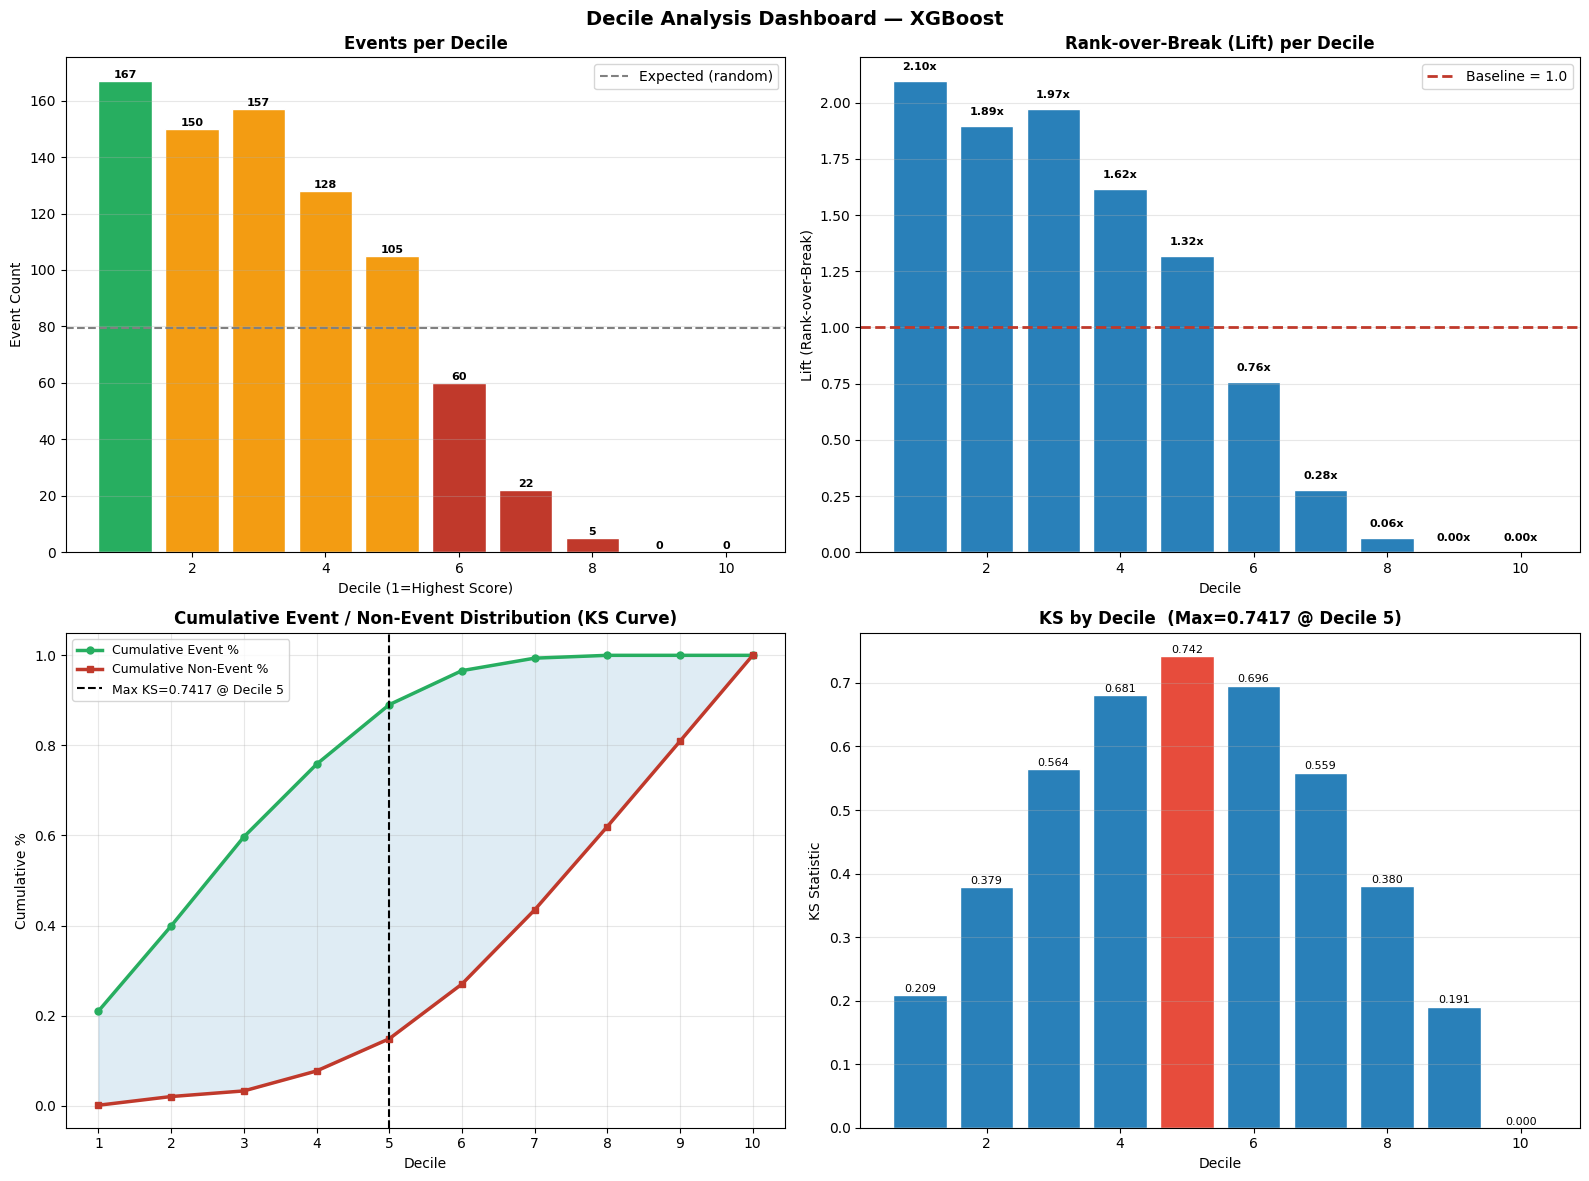

In [29]:
# Decile Charts — 4 panels
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"Decile Analysis Dashboard — {best_name}", fontsize=14, fontweight='bold')

dec = dec_table.copy()

# Panel 1: Events per Decile vs Expected
ax1 = axes[0][0]
bar_colors = ['#27AE60' if rob>=2 else '#F39C12' if rob>=1 else '#C0392B'
              for rob in dec['Rank_over_Break']]
bars = ax1.bar(dec['Decile'], dec['Events'], color=bar_colors, edgecolor='white')
baseline_n = dec['N'].mean() * dec_table['target'].mean() if hasattr(dec_table,'target')     else dec['Events'].mean()
ax1.axhline(dec['Events'].mean(), color='gray', ls='--', label='Expected (random)')
ax1.set_title("Events per Decile", fontweight='bold')
ax1.set_xlabel("Decile (1=Highest Score)"); ax1.set_ylabel("Event Count")
ax1.legend(); ax1.grid(axis='y', alpha=0.3)
for b, v in zip(bars, dec['Events']):
    ax1.text(b.get_x()+b.get_width()/2, v+1, str(int(v)),
             ha='center', fontsize=8, fontweight='bold')

# Panel 2: Conversion Rate (Rank-over-Break)
ax2 = axes[0][1]
ax2.bar(dec['Decile'], dec['Rank_over_Break'], color='#2980B9', edgecolor='white')
ax2.axhline(1.0, color='#C0392B', ls='--', lw=2, label='Baseline = 1.0')
ax2.set_title("Rank-over-Break (Lift) per Decile", fontweight='bold')
ax2.set_xlabel("Decile"); ax2.set_ylabel("Lift (Rank-over-Break)")
ax2.legend(); ax2.grid(axis='y', alpha=0.3)
for i, (_, row) in enumerate(dec.iterrows()):
    ax2.text(row['Decile'], row['Rank_over_Break']+0.05,
             f"{row['Rank_over_Break']:.2f}x", ha='center', fontsize=8, fontweight='bold')

# Panel 3: KS by Decile
ax3 = axes[1][0]
ax3.plot(dec['Cum_Event_Pct'],    color='#27AE60', lw=2.5, marker='o',
         ms=5, label='Cumulative Event %')
ax3.plot(dec['Cum_NonEvent_Pct'], color='#C0392B', lw=2.5, marker='s',
         ms=5, label='Cumulative Non-Event %')
ax3.fill_between(range(len(dec)), dec['Cum_Event_Pct'], dec['Cum_NonEvent_Pct'],
                 alpha=0.15, color='#2980B9')
ax3.set_xticks(range(len(dec))); ax3.set_xticklabels(dec['Decile'])
ax3.axvline(dec['KS'].idxmax(), color='black', ls='--', lw=1.5,
            label=f'Max KS={max_ks_val:.4f} @ Decile {max_ks_dec}')
ax3.set_title("Cumulative Event / Non-Event Distribution (KS Curve)", fontweight='bold')
ax3.set_xlabel("Decile"); ax3.set_ylabel("Cumulative %")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# Panel 4: KS value per decile (bar)
ax4 = axes[1][1]
ks_colors = ['#E74C3C' if d==max_ks_dec else '#2980B9' for d in dec['Decile']]
ax4.bar(dec['Decile'], dec['KS'], color=ks_colors, edgecolor='white')
ax4.set_title(f"KS by Decile  (Max={max_ks_val:.4f} @ Decile {max_ks_dec})",
              fontweight='bold')
ax4.set_xlabel("Decile"); ax4.set_ylabel("KS Statistic")
ax4.grid(axis='y', alpha=0.3)
for _, row in dec.iterrows():
    ax4.text(row['Decile'], row['KS']+0.005, f"{row['KS']:.3f}",
             ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("11_decile_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

KS Change Analysis:
 Decile     KS  KS_Change
      1 0.2092     0.2092
      2 0.3788     0.1696
      3 0.5641     0.1852
      4 0.6810     0.1169
      5 0.7417     0.0607
      6 0.6958    -0.0459
      7 0.5590    -0.1369
      8 0.3802    -0.1787
      9 0.1907    -0.1896
     10 0.0000    -0.1907



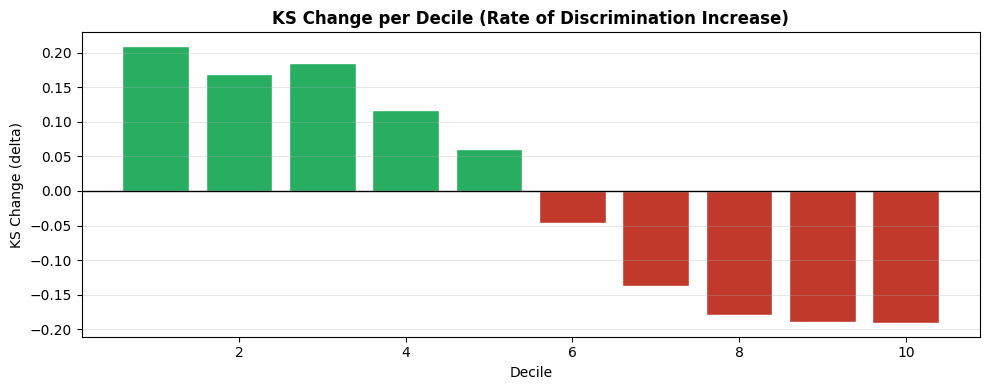

In [30]:
# KS Change (delta KS between consecutive deciles)
dec_table['KS_Change'] = dec_table['KS'].diff().fillna(dec_table['KS'].iloc[0])

print("KS Change Analysis:")
print(dec_table[['Decile','KS','KS_Change']].to_string(index=False))
print()

plt.figure(figsize=(10, 4))
plt.bar(dec_table['Decile'], dec_table['KS_Change'],
        color=['#27AE60' if v>0 else '#C0392B' for v in dec_table['KS_Change']],
        edgecolor='white')
plt.axhline(0, color='black', lw=1)
plt.xlabel("Decile"); plt.ylabel("KS Change (delta)")
plt.title("KS Change per Decile (Rate of Discrimination Increase)",
          fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("12_ks_change.png", dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Top-3 Decile Summary
top3 = dec_table[dec_table['Decile'] <= 3]
total_events = dec_table['Events'].sum()

print("=" * 55)
print("TOP-3 DECILE CONVERSION ANALYSIS")
print("=" * 55)
print(f"  Total subscribers in dataset   : {total_events:,}")
print(f"  Subscribers in top 3 deciles   : {top3['Events'].sum():,}")
print(f"  Top-3 Decile Capture Rate      : {top3_pct:.1f}%")
print(f"  Avg Conversion in top 3 deciles: "
      f"{top3['Conversion_Rate'].mean()*100:.1f}%")
print(f"  Overall Conversion Rate        : "
      f"{dec_table['Conversion_Rate'].mean()*100:.1f}%")
print()
print("By Decile:")
print(top3[['Decile','N','Events','Conversion_Rate',
            'Rank_over_Break']].to_string(index=False))

TOP-3 DECILE CONVERSION ANALYSIS
  Total subscribers in dataset   : 794
  Subscribers in top 3 deciles   : 474
  Top-3 Decile Capture Rate      : 59.7%
  Avg Conversion in top 3 deciles: 94.2%
  Overall Conversion Rate        : 47.4%

By Decile:
 Decile   N  Events  Conversion_Rate  Rank_over_Break
      1 168     167           0.9940           2.0970
      2 167     150           0.8982           1.8948
      3 168     157           0.9345           1.9714


In [32]:
df['deposit'].value_counts()

,count
deposit,
False,5873
True,5289


---
## Section 9: SHAP Explainability

In [33]:
# SHAP — TreeExplainer for XGBoost/LightGBM
shap_model = trained_models.get("XGBoost", trained_models.get("LightGBM",
               trained_models[best_name]))
X_shap = X_test.sample(min(600, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(shap_model)
shap_vals = explainer.shap_values(X_shap)

print(f"SHAP computed on {len(X_shap)} test samples.")

SHAP computed on 600 test samples.


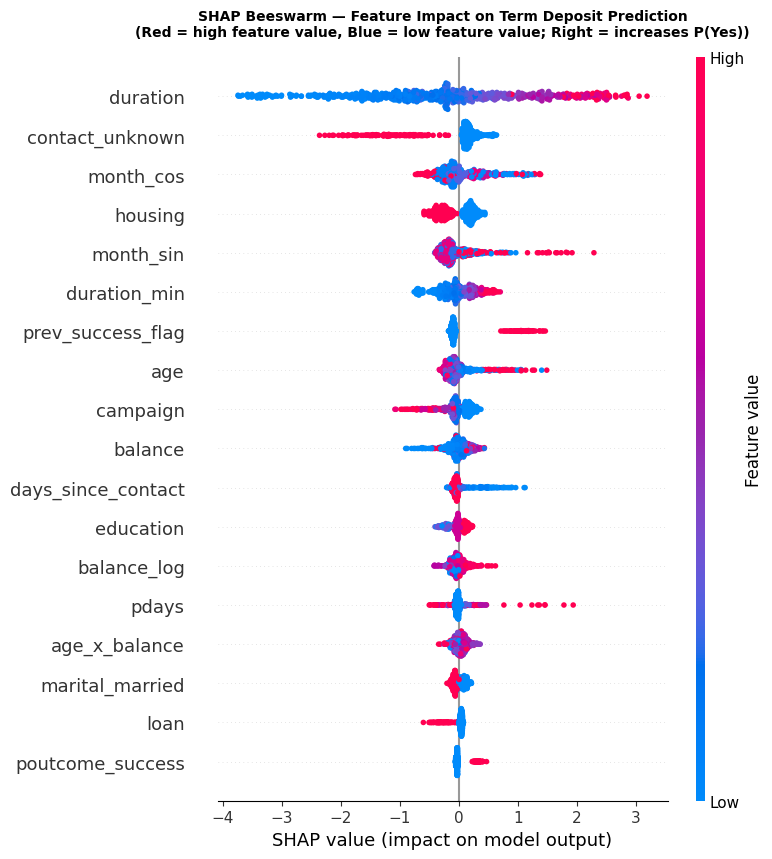

In [34]:
# SHAP Beeswarm Plot
plt.figure(figsize=(11, 9))
shap.summary_plot(shap_vals, X_shap, max_display=18, show=False, plot_type="dot")
plt.title("SHAP Beeswarm — Feature Impact on Term Deposit Prediction\n"
          "(Red = high feature value, Blue = low feature value; "
          "Right = increases P(Yes))",
          fontsize=10, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("13_shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

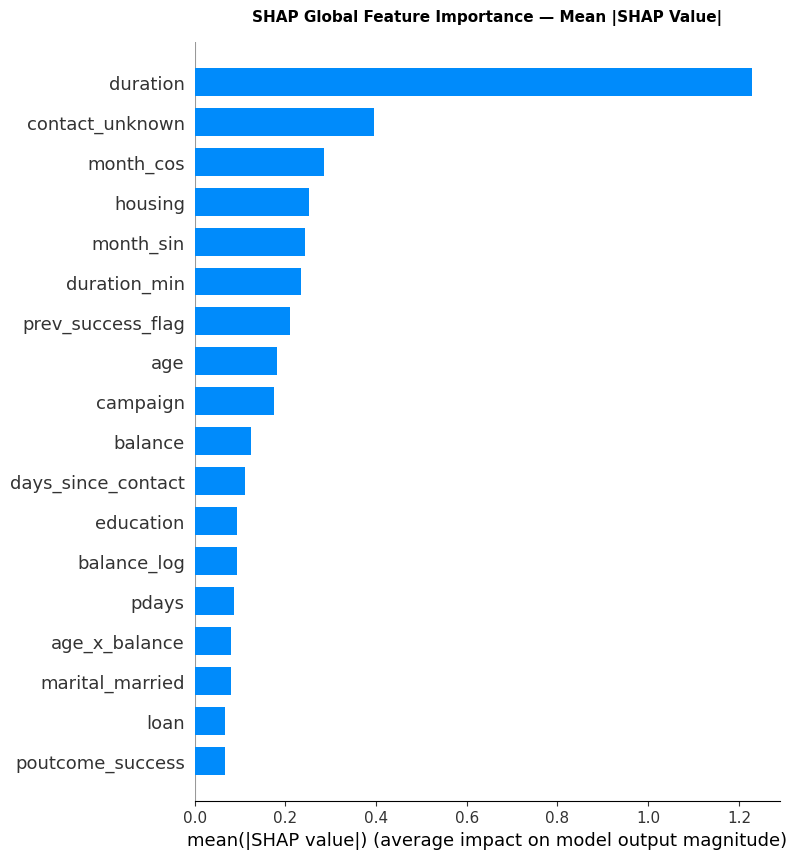

In [35]:
# SHAP Global Bar (mean |SHAP|)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_shap, max_display=18, show=False, plot_type="bar")
plt.title("SHAP Global Feature Importance — Mean |SHAP Value|",
          fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("14_shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()

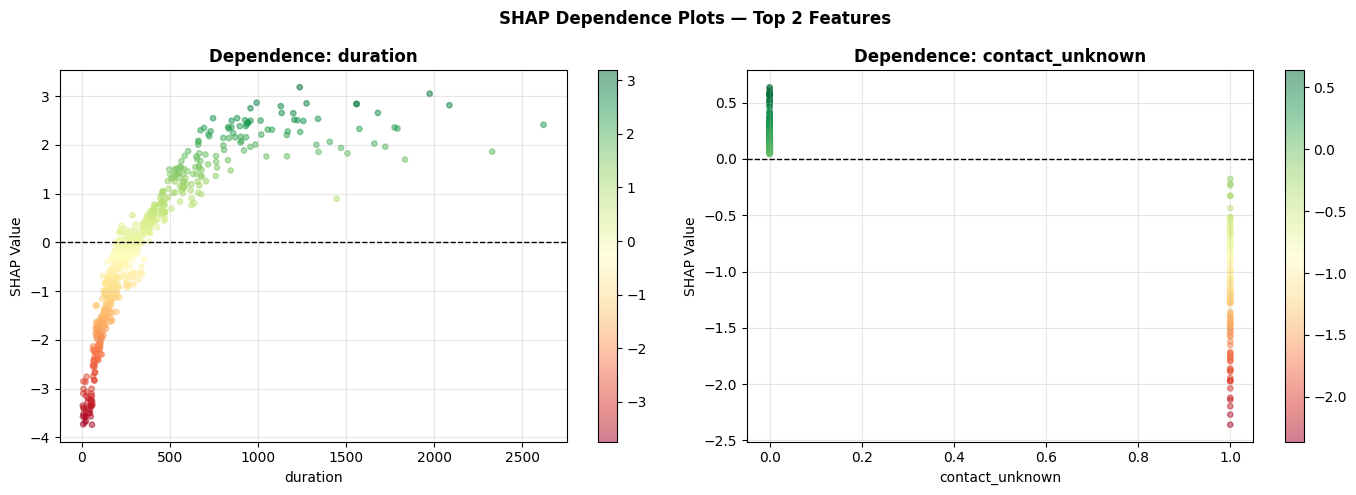

In [36]:
# SHAP Dependence Plot — top 2 features
top2_shap = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

top_feat1 = top2_shap.iloc[0]['feature']
top_feat2 = top2_shap.iloc[1]['feature']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SHAP Dependence Plots — Top 2 Features", fontsize=12, fontweight='bold')

for ax, feat in zip(axes, [top_feat1, top_feat2]):
    feat_idx = list(X_shap.columns).index(feat)
    sc = ax.scatter(X_shap[feat], shap_vals[:, feat_idx],
                    c=shap_vals[:, feat_idx], cmap='RdYlGn',
                    alpha=0.5, s=15)
    plt.colorbar(sc, ax=ax)
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.set_xlabel(feat); ax.set_ylabel("SHAP Value")
    ax.set_title(f"Dependence: {feat}", fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("15_shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()

Explaining prediction for customer index 0:
  Actual   : NO
  Predicted Score: 0.0780



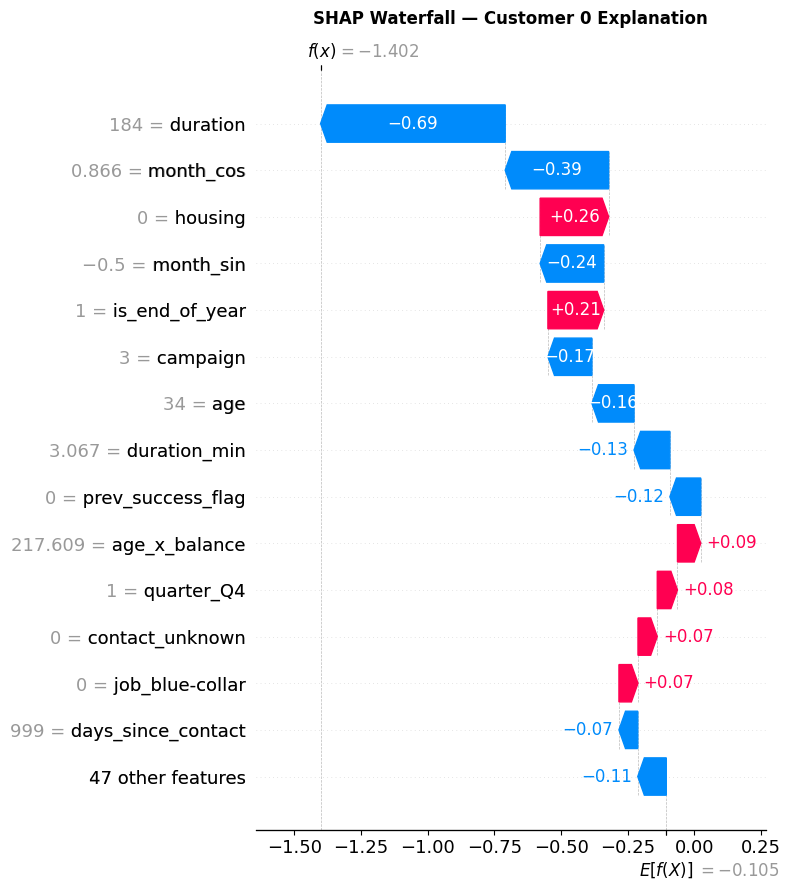

In [37]:
# SHAP Waterfall — single customer explanation
sample_idx = 0
print(f"Explaining prediction for customer index {sample_idx}:")
print(f"  Actual   : {'YES' if y_test.values[sample_idx]==1 else 'NO'}")
print(f"  Predicted Score: {test_proba[sample_idx]:.4f}")
print()

shap_exp = shap.Explanation(
    values     = shap_vals[sample_idx],
    base_values= explainer.expected_value,
    data       = X_shap.iloc[sample_idx],
    feature_names=list(X_shap.columns)
)
plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f"SHAP Waterfall — Customer {sample_idx} Explanation",
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("16_shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10: Threshold Tuning

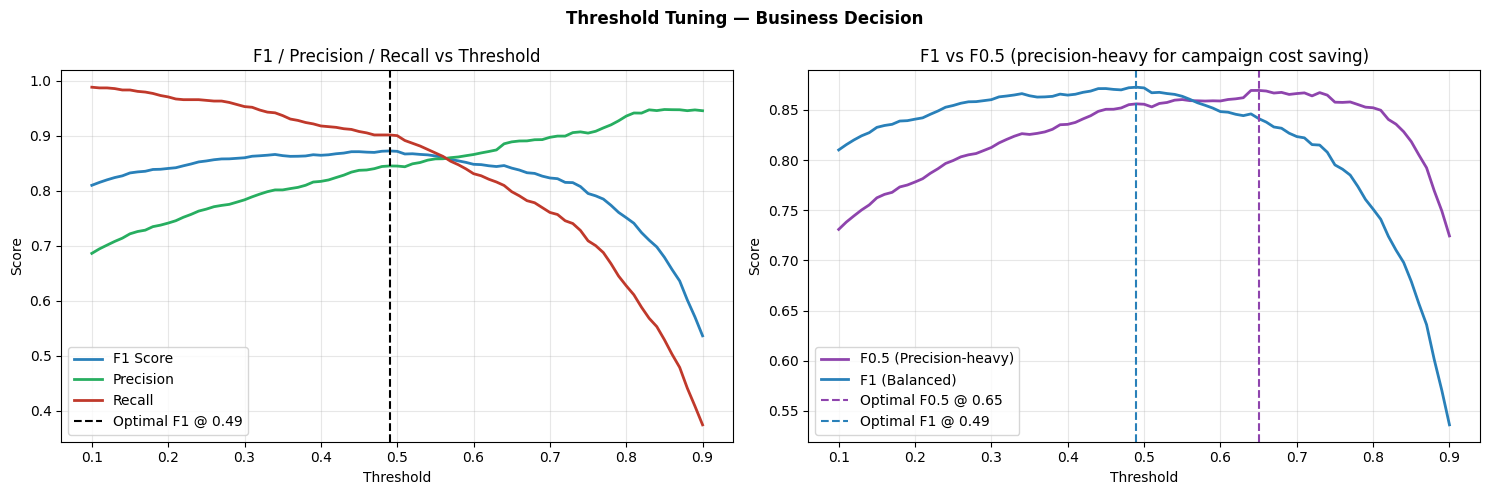

Chosen Threshold (F1-optimal): 0.49
              precision    recall  f1-score   support

          No       0.91      0.85      0.88       881
         Yes       0.85      0.90      0.87       794

    accuracy                           0.88      1675
   macro avg       0.88      0.88      0.88      1675
weighted avg       0.88      0.88      0.88      1675



In [38]:
# Sweep thresholds — maximise F1
thresholds = np.arange(0.1, 0.91, 0.01)
f1s, precs, recs, f05s = [], [], [], []

for t in thresholds:
    pred = (test_proba >= t).astype(int)
    f1s.append(f1_score(y_test, pred, zero_division=0))
    precs.append(precision_score(y_test, pred, zero_division=0))
    recs.append(recall_score(y_test, pred, zero_division=0))
    # F0.5 weights precision 2x over recall (useful in marketing campaigns)
    p, r = precs[-1], recs[-1]
    b = 0.5
    f05s.append((1+b**2)*p*r / max(b**2*p + r, 1e-9))

opt_f1_idx  = np.argmax(f1s)
opt_f05_idx = np.argmax(f05s)
opt_thr_f1  = thresholds[opt_f1_idx]
opt_thr_f05 = thresholds[opt_f05_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Threshold Tuning — Business Decision", fontsize=12, fontweight='bold')

axes[0].plot(thresholds, f1s,   color='#2980B9', lw=2, label='F1 Score')
axes[0].plot(thresholds, precs, color='#27AE60', lw=2, label='Precision')
axes[0].plot(thresholds, recs,  color='#C0392B', lw=2, label='Recall')
axes[0].axvline(opt_thr_f1, color='black', ls='--',
                label=f'Optimal F1 @ {opt_thr_f1:.2f}')
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("F1 / Precision / Recall vs Threshold")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, f05s, color='#8E44AD', lw=2, label='F0.5 (Precision-heavy)')
axes[1].plot(thresholds, f1s,  color='#2980B9', lw=2, label='F1 (Balanced)')
axes[1].axvline(opt_thr_f05, color='#8E44AD', ls='--',
                label=f'Optimal F0.5 @ {opt_thr_f05:.2f}')
axes[1].axvline(opt_thr_f1, color='#2980B9', ls='--',
                label=f'Optimal F1 @ {opt_thr_f1:.2f}')
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("F1 vs F0.5 (precision-heavy for campaign cost saving)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("17_threshold.png", dpi=150, bbox_inches='tight')
plt.show()

opt_thr = opt_thr_f1  # use F1-optimal for final scoring
final_pred = (test_proba >= opt_thr).astype(int)
print(f"Chosen Threshold (F1-optimal): {opt_thr:.2f}")
print(classification_report(y_test, final_pred, target_names=['No','Yes']))

---
## Section 11: Population Stability Index (PSI)

**PSI measures how much the score distribution has shifted between two populations.**  
This is critical in banking to detect:
- Model drift after deployment
- Distribution shift between training and production data

**PSI Interpretation:**
| PSI | Meaning |
|---|---|
| < 0.10 | No significant change — model stable |
| 0.10 – 0.25 | Some shift — monitor closely |
| > 0.25 | Major shift — model likely needs retraining |


In [39]:
def compute_psi(expected_scores, actual_scores, buckets=10):
    """
    Compute Population Stability Index between two score distributions.
    expected = train/reference distribution
    actual   = test/production distribution
    """
    # Create bins from expected (train) distribution
    breakpoints = np.percentile(expected_scores,
                                np.linspace(0, 100, buckets+1))
    breakpoints = np.unique(breakpoints)

    def get_bucket_counts(scores, bp):
        counts = np.zeros(len(bp)-1)
        for i in range(len(bp)-1):
            lo, hi = bp[i], bp[i+1]
            if i == 0:
                counts[i] = ((scores >= lo) & (scores <= hi)).sum()
            else:
                counts[i] = ((scores > lo) & (scores <= hi)).sum()
        return counts

    exp_counts = get_bucket_counts(expected_scores, breakpoints)
    act_counts = get_bucket_counts(actual_scores,   breakpoints)

    exp_pct = (exp_counts / len(expected_scores)).clip(1e-6)
    act_pct = (act_counts / len(actual_scores)).clip(1e-6)

    psi_bins  = (act_pct - exp_pct) * np.log(act_pct / exp_pct)
    psi_total = psi_bins.sum()

    psi_df = pd.DataFrame({
        'Bucket'       : range(1, len(psi_bins)+1),
        'Score_Low'    : breakpoints[:-1],
        'Score_High'   : breakpoints[1:],
        'Expected_Pct' : exp_pct,
        'Actual_Pct'   : act_pct,
        'PSI_Bin'      : psi_bins
    })
    return psi_total, psi_df

# Train scores as "expected", test scores as "actual" (simulating deployment)
Xtr_psi = X_train_sc if "Logistic" in best_name else X_train
train_proba_psi = trained_models[best_name].predict_proba(Xtr_psi)[:,1]

psi_val, psi_df = compute_psi(train_proba_psi, test_proba)

def psi_label(p):
    if p < 0.10: return "STABLE — No Action Needed"
    elif p < 0.25: return "MONITOR — Some Shift Detected"
    else: return "ALERT — Model Retraining Recommended"

print(f"PSI (Train vs Test): {psi_val:.4f}")
print(f"Status             : {psi_label(psi_val)}")
print()
print(psi_df.to_string(index=False))

PSI (Train vs Test): 0.0028
Status             : STABLE — No Action Needed

 Bucket  Score_Low  Score_High  Expected_Pct  Actual_Pct  PSI_Bin
      1     0.0004      0.0094        0.1000      0.0979   0.0000
      2     0.0094      0.0246        0.1000      0.0961   0.0002
      3     0.0246      0.0833        0.0999      0.1081   0.0006
      4     0.0833      0.2524        0.1000      0.1027   0.0001
      5     0.2524      0.5135        0.1000      0.0967   0.0001
      6     0.5135      0.7093        0.0999      0.0991   0.0000
      7     0.7093      0.8219        0.1000      0.1057   0.0003
      8     0.8219      0.8913        0.0999      0.0931   0.0005
      9     0.8913      0.9402        0.1000      0.0931   0.0005
     10     0.9402      0.9975        0.1000      0.1069   0.0005


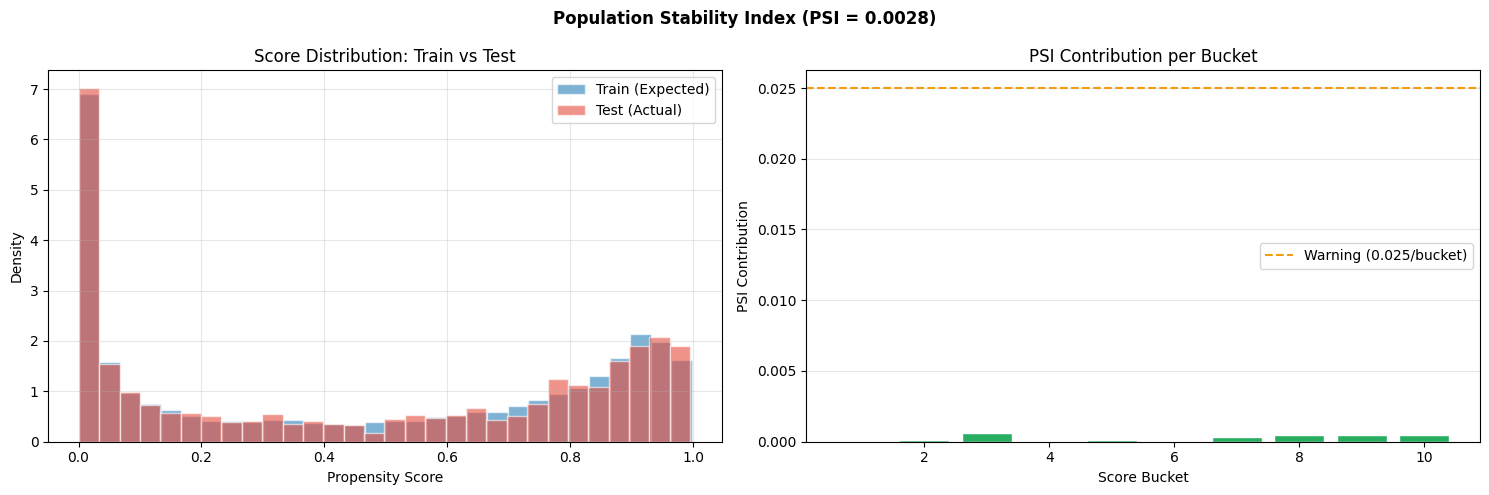

In [40]:
# PSI Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f"Population Stability Index (PSI = {psi_val:.4f})",
             fontsize=12, fontweight='bold')

# Score distributions overlay
axes[0].hist(train_proba_psi, bins=30, alpha=0.6, density=True,
             color='#2980B9', label='Train (Expected)', edgecolor='white')
axes[0].hist(test_proba,      bins=30, alpha=0.6, density=True,
             color='#E74C3C', label='Test (Actual)', edgecolor='white')
axes[0].set_xlabel("Propensity Score"); axes[0].set_ylabel("Density")
axes[0].set_title("Score Distribution: Train vs Test")
axes[0].legend(); axes[0].grid(alpha=0.3)

# PSI per bucket
axes[1].bar(psi_df['Bucket'], psi_df['PSI_Bin'],
            color=['#C0392B' if v>0.025 else '#F39C12' if v>0.01 else '#27AE60'
                   for v in psi_df['PSI_Bin']],
            edgecolor='white')
axes[1].axhline(0.025, color='#F39C12', ls='--', lw=1.5, label='Warning (0.025/bucket)')
axes[1].set_xlabel("Score Bucket"); axes[1].set_ylabel("PSI Contribution")
axes[1].set_title(f"PSI Contribution per Bucket")
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("18_psi.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Section 12: Model Scorecard Summary (Banking Format)

In [41]:
# Full Banking Scorecard Report
auc_final   = roc_auc_score(y_test, test_proba)
gini_final  = 2 * auc_final - 1
fpr_f, tpr_f, _ = roc_curve(y_test, test_proba)
ks_final    = float(np.max(tpr_f - fpr_f))

final_pred_sc = (test_proba >= opt_thr).astype(int)
f1_final    = f1_score(y_test, final_pred_sc)
prec_final  = precision_score(y_test, final_pred_sc)
rec_final   = recall_score(y_test, final_pred_sc)

print("=" * 65)
print("   TERM DEPOSIT PROPENSITY MODEL — SCORECARD REPORT")
print("=" * 65)
print(f"  Model Name         : {best_name}")
print(f"  Dataset            : UCI Bank Marketing (11,162 records)")
print(f"  Test Set Size      : {len(y_test):,} records")
print()
print("  --- DISCRIMINATION METRICS ---")
print(f"  AUC-ROC            : {auc_final:.4f}")
print(f"  Gini Coefficient   : {gini_final:.4f}  (2xAUC - 1)")
print(f"  KS Statistic       : {ks_final:.4f}")
print(f"  Max KS Decile      : Decile {max_ks_dec}")
print()
print("  --- CLASSIFICATION METRICS (threshold={:.2f}) ---".format(opt_thr))
print(f"  F1 Score           : {f1_final:.4f}")
print(f"  Precision          : {prec_final:.4f}")
print(f"  Recall             : {rec_final:.4f}")
print()
print("  --- DECILE PERFORMANCE ---")
print(f"  Top-3 Decile Capture: {top3_pct:.1f}% of all subscribers")
print(f"  Top-1 Decile RoB   : {dec_table.iloc[0]['Rank_over_Break']:.2f}x baseline")
print()
print("  --- STABILITY ---")
print(f"  PSI (Train vs Test): {psi_val:.4f}  [{psi_label(psi_val)}]")
print()
print("  --- IV SUMMARY (Top 5 Features) ---")
for _, row in iv_df.head(5).iterrows():
    print(f"  {row['feature']:<20}: IV={row['IV']:.4f}  ({row['Predictive_Power']})")
print("=" * 65)

   TERM DEPOSIT PROPENSITY MODEL — SCORECARD REPORT
  Model Name         : XGBoost
  Dataset            : UCI Bank Marketing (11,162 records)
  Test Set Size      : 1,675 records

  --- DISCRIMINATION METRICS ---
  AUC-ROC            : 0.9424
  Gini Coefficient   : 0.8849  (2xAUC - 1)
  KS Statistic       : 0.7531
  Max KS Decile      : Decile 5

  --- CLASSIFICATION METRICS (threshold=0.49) ---
  F1 Score           : 0.8726
  Precision          : 0.8453
  Recall             : 0.9018

  --- DECILE PERFORMANCE ---
  Top-3 Decile Capture: 59.7% of all subscribers
  Top-1 Decile RoB   : 2.10x baseline

  --- STABILITY ---
  PSI (Train vs Test): 0.0028  [STABLE — No Action Needed]

  --- IV SUMMARY (Top 5 Features) ---
  poutcome            : IV=0.4793  (Strong)
  month               : IV=0.4418  (Strong)
  contact             : IV=0.2923  (Medium)
  pdays               : IV=0.2231  (Medium)
  previous            : IV=0.2155  (Medium)


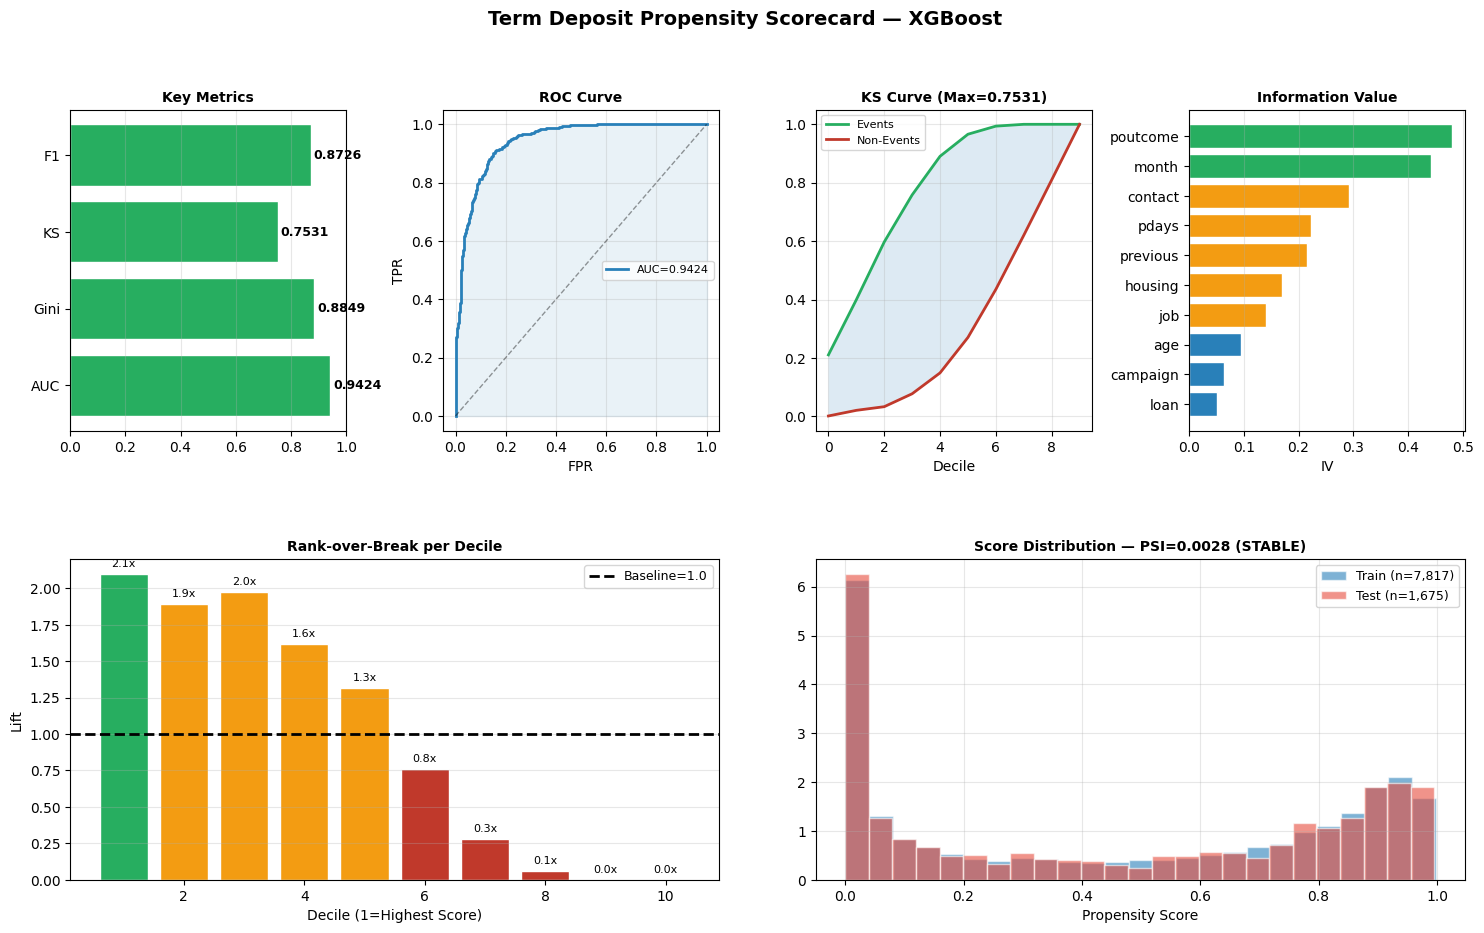

In [42]:
# Scorecard Dashboard Visual
fig = plt.figure(figsize=(18, 10))
fig.suptitle(f"Term Deposit Propensity Scorecard — {best_name}",
             fontsize=14, fontweight='bold')
gs = fig.add_gridspec(2, 4, hspace=0.4, wspace=0.35)

# Panel 1: Gauge-style AUC
ax1 = fig.add_subplot(gs[0, 0])
metrics_vals = [auc_final, gini_final, ks_final, f1_final]
metrics_lbls = ['AUC', 'Gini', 'KS', 'F1']
colors_gauge = ['#27AE60' if v>0.75 else '#F39C12' if v>0.60 else '#C0392B'
                for v in metrics_vals]
bars = ax1.barh(metrics_lbls, metrics_vals, color=colors_gauge, edgecolor='white')
ax1.set_xlim(0, 1)
ax1.set_title("Key Metrics", fontweight='bold', fontsize=10)
for b, v in zip(bars, metrics_vals):
    ax1.text(v+0.01, b.get_y()+b.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Panel 2: ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fpr_f, tpr_f, color='#2980B9', lw=2,
         label=f'AUC={auc_final:.4f}')
ax2.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax2.fill_between(fpr_f, tpr_f, alpha=0.1, color='#2980B9')
ax2.set_title("ROC Curve", fontweight='bold', fontsize=10)
ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# Panel 3: KS Curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(dec_table['Cum_Event_Pct'],    color='#27AE60', lw=2, label='Events')
ax3.plot(dec_table['Cum_NonEvent_Pct'], color='#C0392B', lw=2, label='Non-Events')
ax3.fill_between(range(10), dec_table['Cum_Event_Pct'],
                 dec_table['Cum_NonEvent_Pct'], alpha=0.15)
ax3.set_title(f"KS Curve (Max={ks_final:.4f})", fontweight='bold', fontsize=10)
ax3.set_xlabel("Decile"); ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# Panel 4: IV Top 10
ax4 = fig.add_subplot(gs[0, 3])
top10_iv = iv_df.head(10)
iv_colors = ['#27AE60' if v>=0.30 else '#F39C12' if v>=0.10 else '#2980B9'
             for v in top10_iv['IV']]
ax4.barh(top10_iv['feature'][::-1], top10_iv['IV'][::-1],
         color=iv_colors[::-1], edgecolor='white')
ax4.set_title("Information Value", fontweight='bold', fontsize=10)
ax4.set_xlabel("IV"); ax4.grid(axis='x', alpha=0.3)

# Panel 5: Decile Lift
ax5 = fig.add_subplot(gs[1, 0:2])
bar_c = ['#27AE60' if r>=2 else '#F39C12' if r>=1 else '#C0392B'
         for r in dec_table['Rank_over_Break']]
ax5.bar(dec_table['Decile'], dec_table['Rank_over_Break'],
        color=bar_c, edgecolor='white')
ax5.axhline(1, color='black', ls='--', lw=2, label='Baseline=1.0')
ax5.set_title("Rank-over-Break per Decile", fontweight='bold', fontsize=10)
ax5.set_xlabel("Decile (1=Highest Score)"); ax5.set_ylabel("Lift")
ax5.legend(fontsize=9); ax5.grid(axis='y', alpha=0.3)
for _, row in dec_table.iterrows():
    ax5.text(row['Decile'], row['Rank_over_Break']+0.05,
             f"{row['Rank_over_Break']:.1f}x", ha='center', fontsize=8)

# Panel 6: PSI Distribution
ax6 = fig.add_subplot(gs[1, 2:4])
ax6.hist(train_proba_psi, bins=25, alpha=0.6, density=True,
         color='#2980B9', label=f'Train (n={len(train_proba_psi):,})', edgecolor='white')
ax6.hist(test_proba, bins=25, alpha=0.6, density=True,
         color='#E74C3C', label=f'Test (n={len(test_proba):,})', edgecolor='white')
ax6.set_title(f"Score Distribution — PSI={psi_val:.4f} ({psi_label(psi_val).split(' —')[0]})",
              fontweight='bold', fontsize=10)
ax6.set_xlabel("Propensity Score"); ax6.legend(fontsize=9); ax6.grid(alpha=0.3)

plt.savefig("19_scorecard_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()